<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**

Anote su hipótesis y compruébela después de ejecutar el notebook.


In [ ]:
# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav



## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [ ]:
!pip install uv

In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro?
2. ¿Cuántos canales tiene?
3. ¿Cómo se llama el canal seleccionado?
4. ¿Cuál es la duración total del registro?
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo?
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos?


Respuestas de preguntas de análisis 1

1) La frecuencia de muestreo del registro es de 360Hz, lo que se refiere que se adquieren 360 muestras de la señal por segundo

2) El registro presenta dos canales, "MLII" y "VS"

3) El canal seleccionado es el "MLII", lo cual se obtiene usando "CHANNEL == 0"

4) La duración total del registro se puede obtener usando la siguiente fórmula: T = N/fs

- Como datos tenemos que fs = 360 y N = 650000, reemplazando:

- T = 650000/360 = 1805.56 s

- Si se quisiese representar en minutos, sería 30.09 minutos

5) Como se menciono anteriormente, se adquieres 360 muestras en 1 segundo

6) Si se seleccionara un segmento de 10 segundos, se obtendrían 3600 muestras



## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


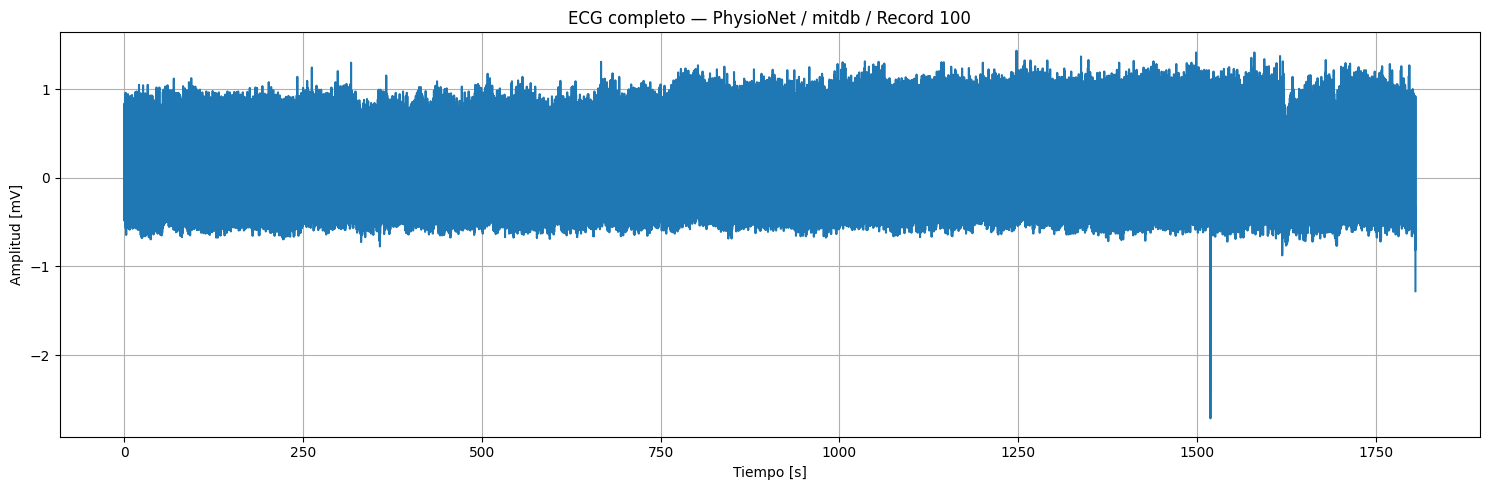

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
2. ¿Se pueden identificar visualmente complejos QRS?
3. ¿La morfología permanece igual durante todo el registro?
4. ¿Se observa ruido?
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?


Respuestas a preguntas de análisis 2

1) La amplitud no es constante, aunque las variaciones en la amplitud no son exageradas. Esto ocurre ya que la actividad eléctrica del corazón es variable y eso condiciona el registro final

2) Si se pueden identificar visualmente los complejos QRS, ya que estos se observarán como cambios de mayor amplitud en la gráfica

3) No permanece igual. Sin embargo, relacionando con lo que se menciona anteriormente, la morfología no tendrá cambios significativos pero las variaciones ocurriran por factores como cambios fisilógicos, ruido en la medición, etc.

4) Si, este se hace presente como ciertas fluctuaciones o perturbaciones en la señal

5) La principal ventaja de visualizar la señal durante varios minutos es que se puede identificar con mayor facilidad cambios en el ritmo cardíaco, en la amplitud o situacione inesperadas que pueden afectar la señal

6) Si se configura una gráfica demasiado extensa entonces se puede perder detalle en cuando se realiza cada latido, en la identificación de QRS y en el mismo análisis de cambios en la amplitud de señal



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


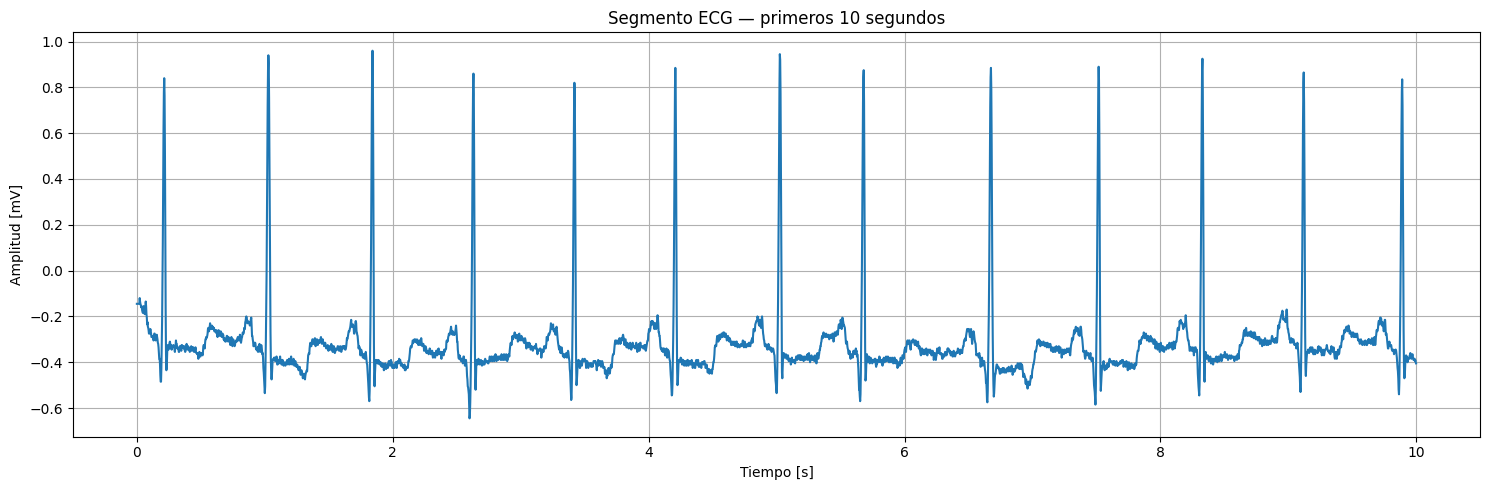

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.


Resolucion

1) Onda P: Se representa como una pequeña elevación antes del complejo QRS

2) Complejo QRS: Se representa como el cambio pronunciado de la señal

3) Onda T: Aparece después del complejo QRS, usualmente como una banda ancha

4) Intervalo entre complejos QRS: Es el tiempo entre cada uno de ellos

5) Posibles artefactos: Alteraciones de la señal

Una vez mencionado lo que representa cada uno:

Al inicio de la señal hay una onda P, para inmediatamente pasar al complejo QRS que va hasta una amplitud aproximada de 0.8 (siempre rondará este número en este caso), donde inmediatamente vemos una banda sin elevación que será la onda T, luego una alteración en la señal que puede deberse debido a algún artefacto, para luego volver a aparecer una onda P. El intervalo entre complejos es de aproximadamente 1.7 segundos. En el ejmplo: el rojo representa la onda P, el verde el complejo QRS, el celeste la ond T y el morado el posible artefacto



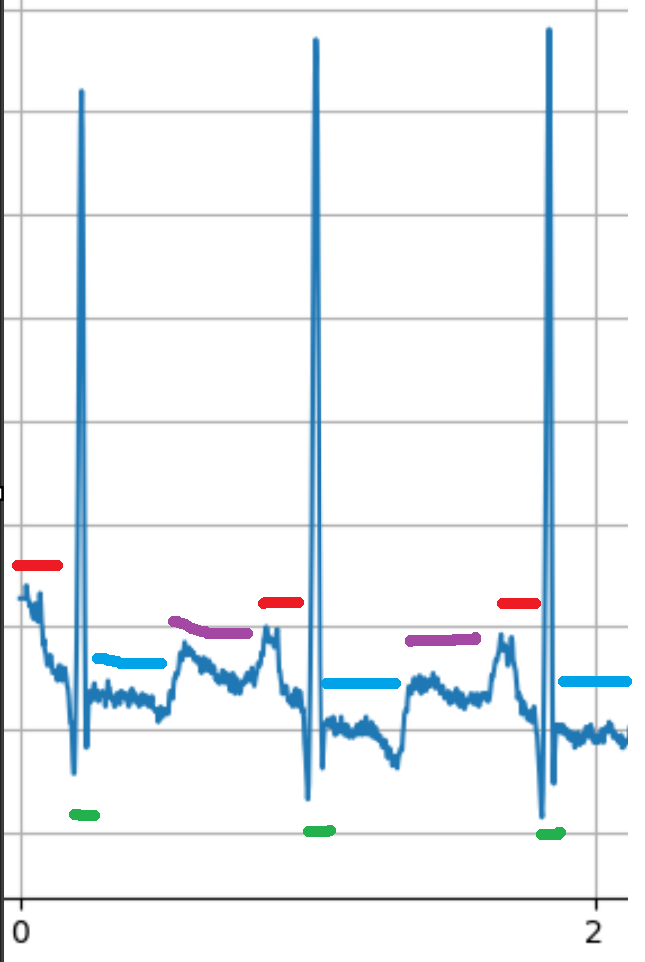


# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


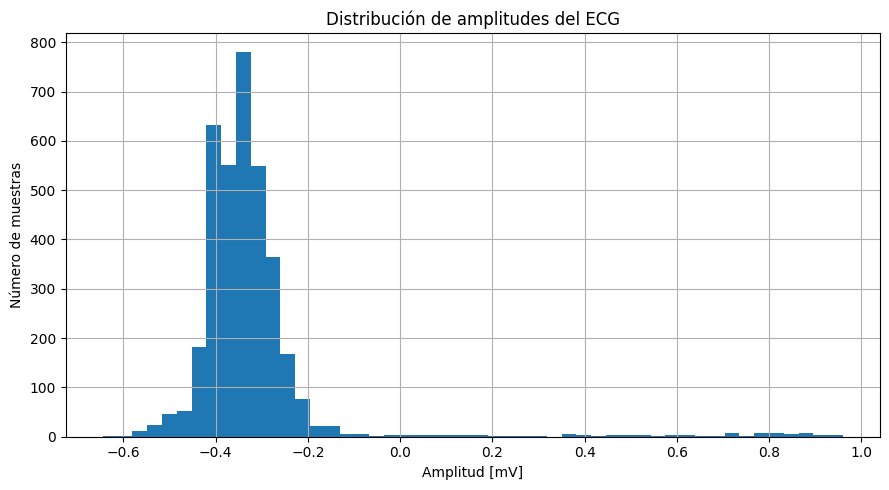

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras?
2. ¿La distribución parece simétrica?
3. ¿Existen valores extremos?
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central?
5. ¿El histograma conserva información temporal? Explique.


Resolución de preguntas de análisis 3

1) La mayor cantidad de muestras se concentran alrededor del rango de -0.5 a -0.2 de amplitud.

2) Tienes cierta morfología simétrica, sobretodo donde se concentran más muestras. Sin embargo, debido a que es un ECG, la asimetría es normal por las diferentes ondas cardíacas.

3) Si los valores extremos asociado con las amplitudes son -0.6 y 1 aproximadamente

4) Los complejos QRS puededn generar ese efecto, o incluso la presencia de ruido o artefactos.

5) No, ya que el histograma muestra la distribución de amplitudes, sin mostrar el momento donde ocurre cada valor en este caso



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


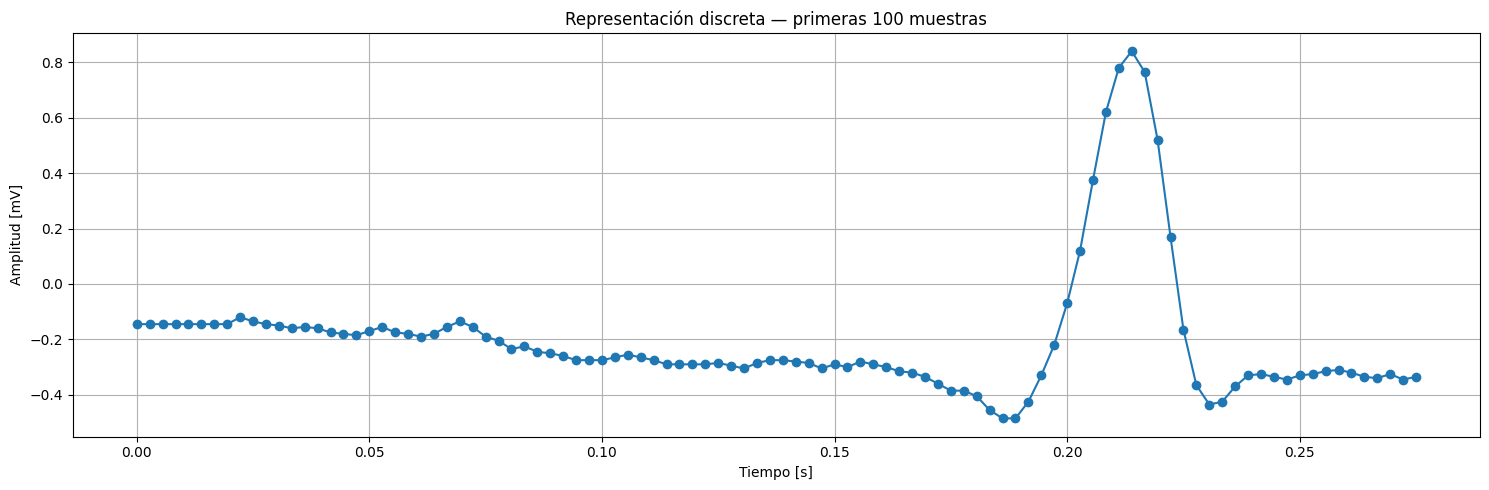

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo?
2. ¿Qué ocurre si aumentamos `fs`?
3. ¿Qué ocurre si disminuimos `fs`?
4. ¿Qué representa el eje `n` en una señal discreta?
5. ¿Cuál es la relación entre `n`, `fs` y `t`?


Resolución de preguntas de análisis 4

1) Existen 360 muestras por segundo, debido al valor de fs

2) Si aumentas el valor de fs, habrán más muestras por segundo, por lo que aumenta la resolución temporal de la gráfica

3) Si disminuyes el valor de fs, habrán menos muestras por segundo, por lo que disminuirá la resoulicón temporal de la gráfica

4) En una señal discreta, n representa el índice de cada muestra

5) La relación es la siguiente: t[n] = n/fs






# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8249
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [ ]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
)
)



### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal?
2. ¿El sonido corresponde a un sonido fisiológico real?
3. ¿Por qué un ECG puede convertirse a WAV?
4. ¿Qué información se conserva al hacer la conversión?
5. ¿Qué información fisiológica podría perderse al escucharla?
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio?


Respuestas a preguntas de análisis 5

1) Se puede escuhar la señal. Sin embargo, el sonido no será natural al estar reproduciendo una señal eléctria

2) No, en realidad. Si bien la señal es ECG, el sonido no correspondrá a un sonido fisológico real, sino e una representación de este sonido

3) Un ECG puede convertirse a WAV, por las características de este tipo de archivo. WAV, es capaz de almacenar muestras de una señal digital

4) Se conserva las relaciones temporales de la señal ECG.

5) Por razones obvias, se perderá la información de la morfología de la señal ECG. Al ser un sonido, no se podrán identificar los elementos que forman esta señal sin la necesidad de visualizar la gráfica

6) La representación gráfica proporciona datos de amplitud, tiempo y elementos de la morfología de la señal. Por otro lado, la reproducción por medio de audio proporcion presiones sonoras, para poder identificar de manera diferente los elementos de la señal


# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [ ]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")



# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:

```python
RECORD = "100"
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.


**Resolución Ejercicio 1**

Cambie el RECORD de 100 a 200

- frecuencia de muestreo: 360 Hz
- número de canales: 2
- nombres de canales: MLII, V1
- morfología: Los picos del nuevo RECORD son más pronunciados a comparación del anterior
- amplitud: La amplitud de este RECORD es mayor que en el anterior. La amplitud va de -2 a 2 mientras en el anterior iba de -1 a 1
- distribución: La distribución es similar al caso anterior

En el caso de los gráficos:

- 1ro: La ampltiud del nuevo RECORD es mayor, se presencian picos más pronunciados

- 2do: La amplitud en el caso anteior iba de -0.4 a 1, mientras en este caso van de -2 a 1. Los complejos QRS van tanto para el lado positivo como hacia el lado negativo de amplitud. Las ondas P aún son notorias. Las ondas T y artefactos aún conservan su presencia

- 3ro: En el caso anterior la concentración del mayor número de muestras iba de -0.6 a -0,2 de amplitud aproximadamente, en este caso va de -0.5 a 0.6 de amplitud.

- 4to: En el caso anterior se presenciaba un pico positivo en la gráfica alrededor de 0.17s a 0.24s. En este caso, hay una caída cerca de los 0s

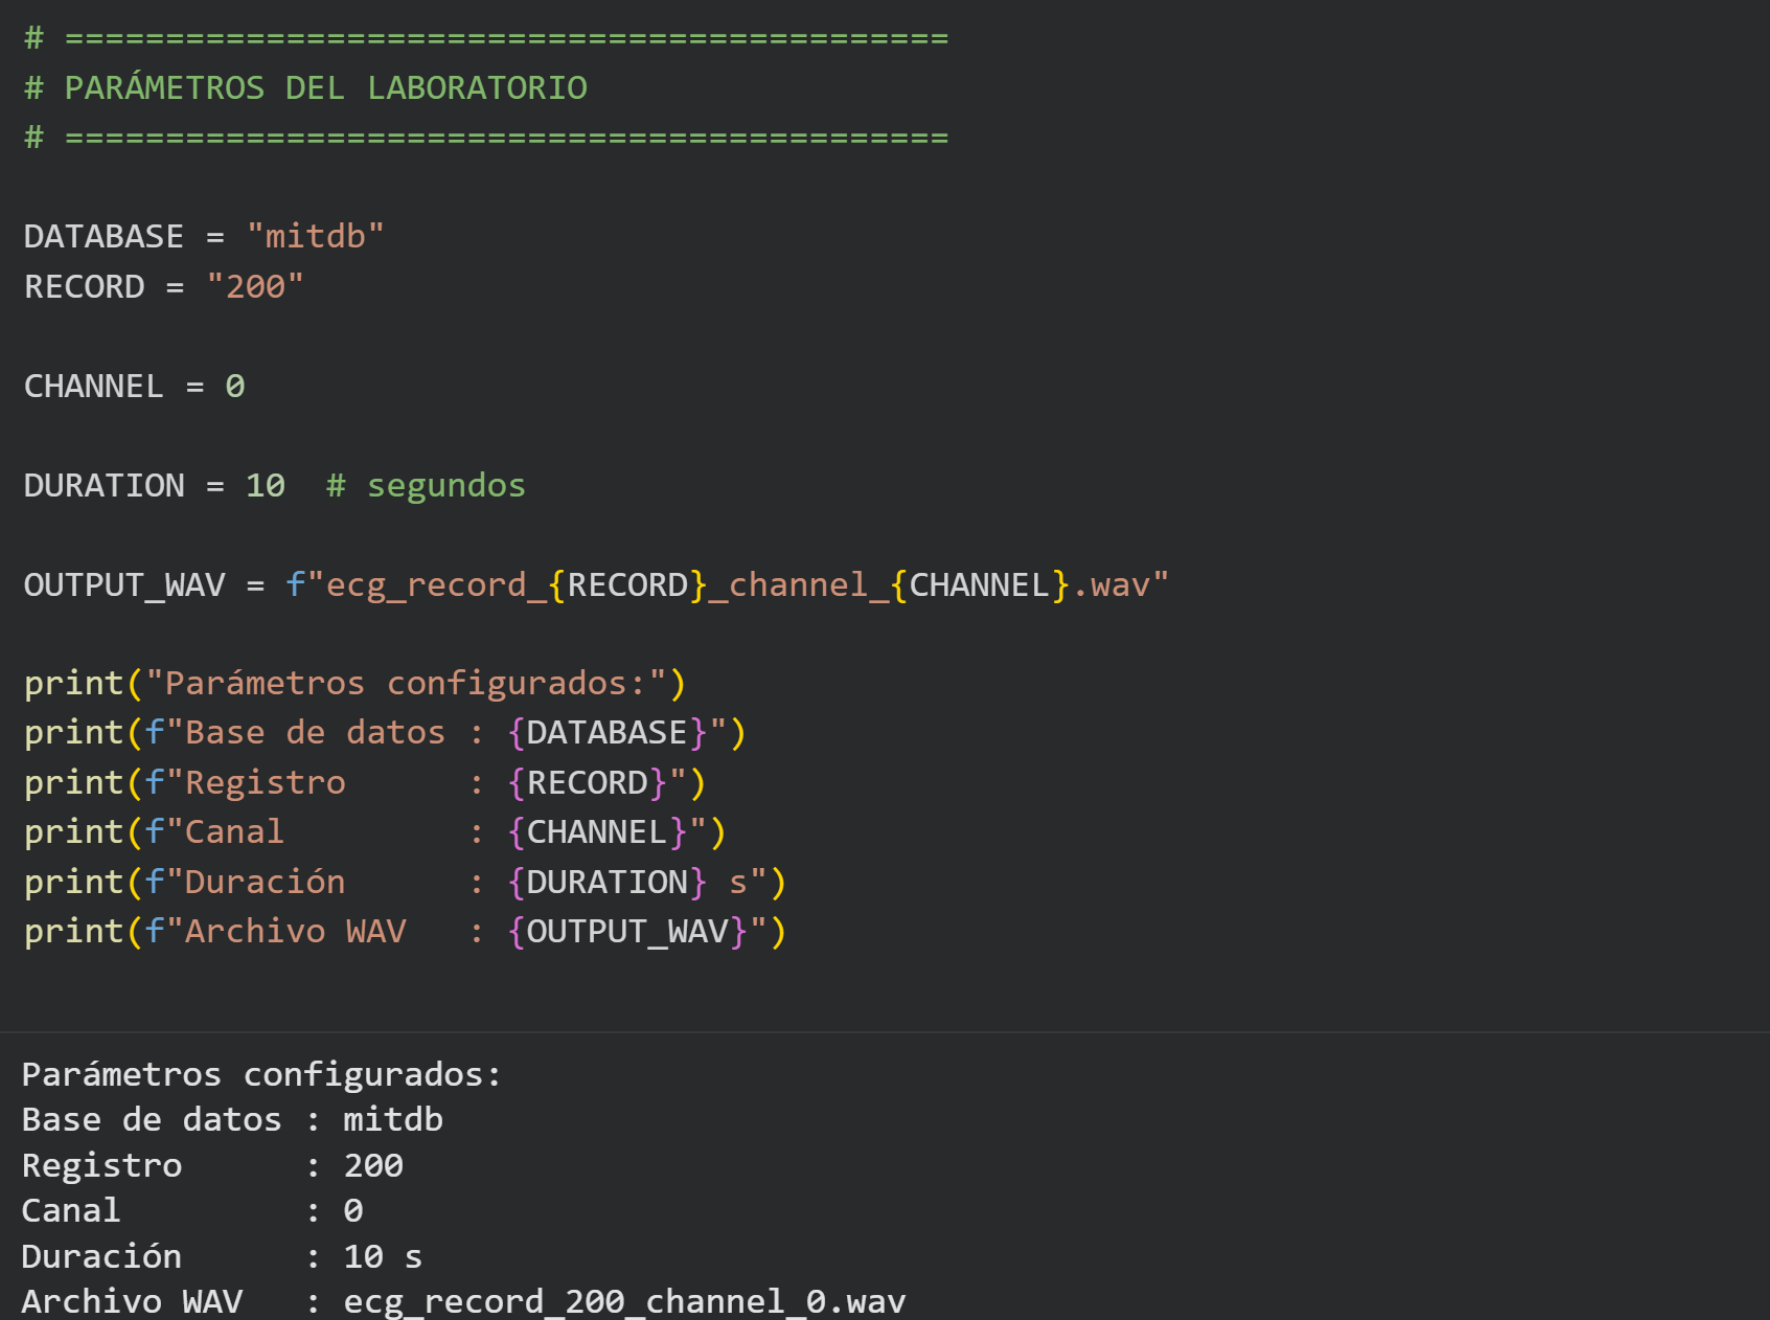

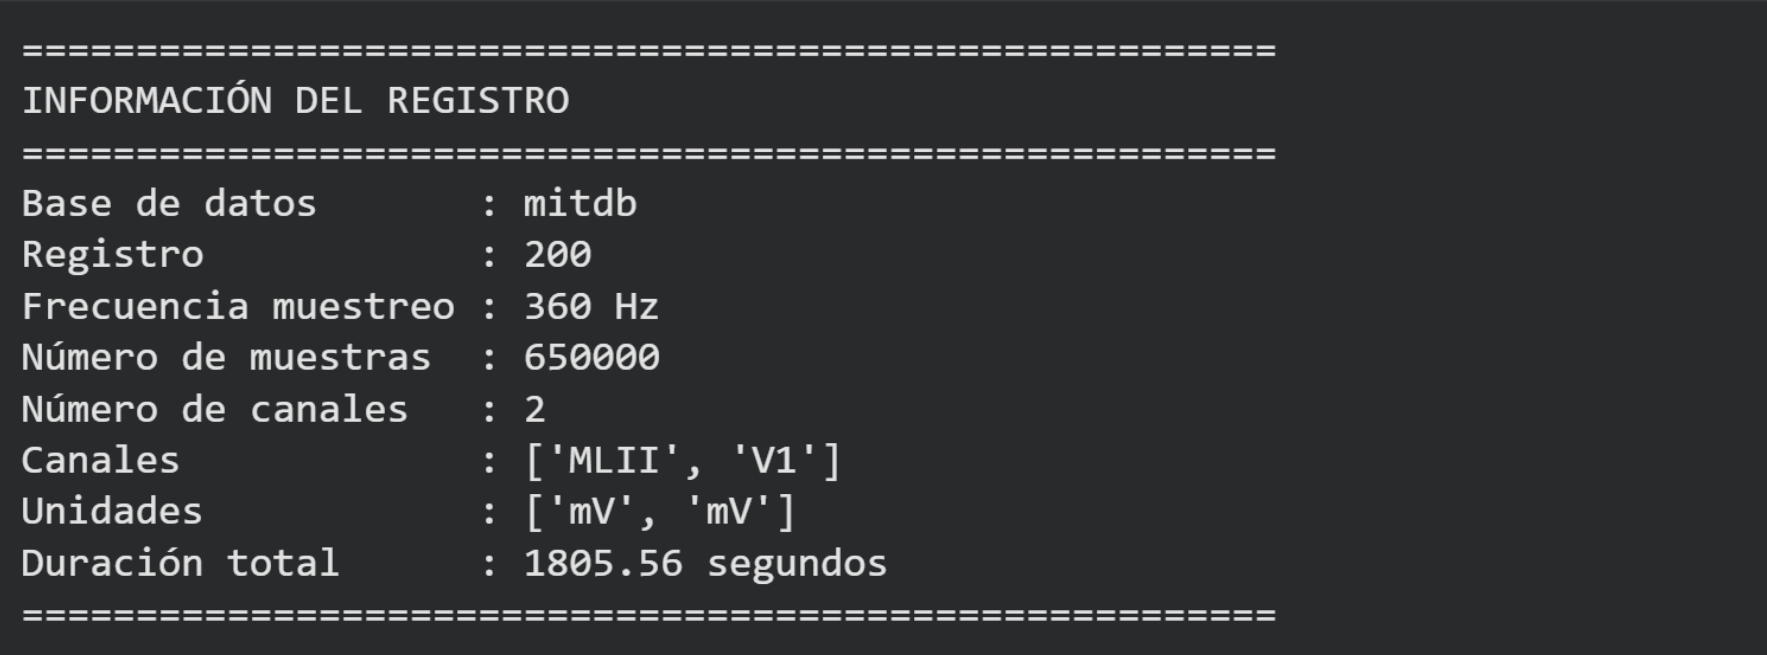

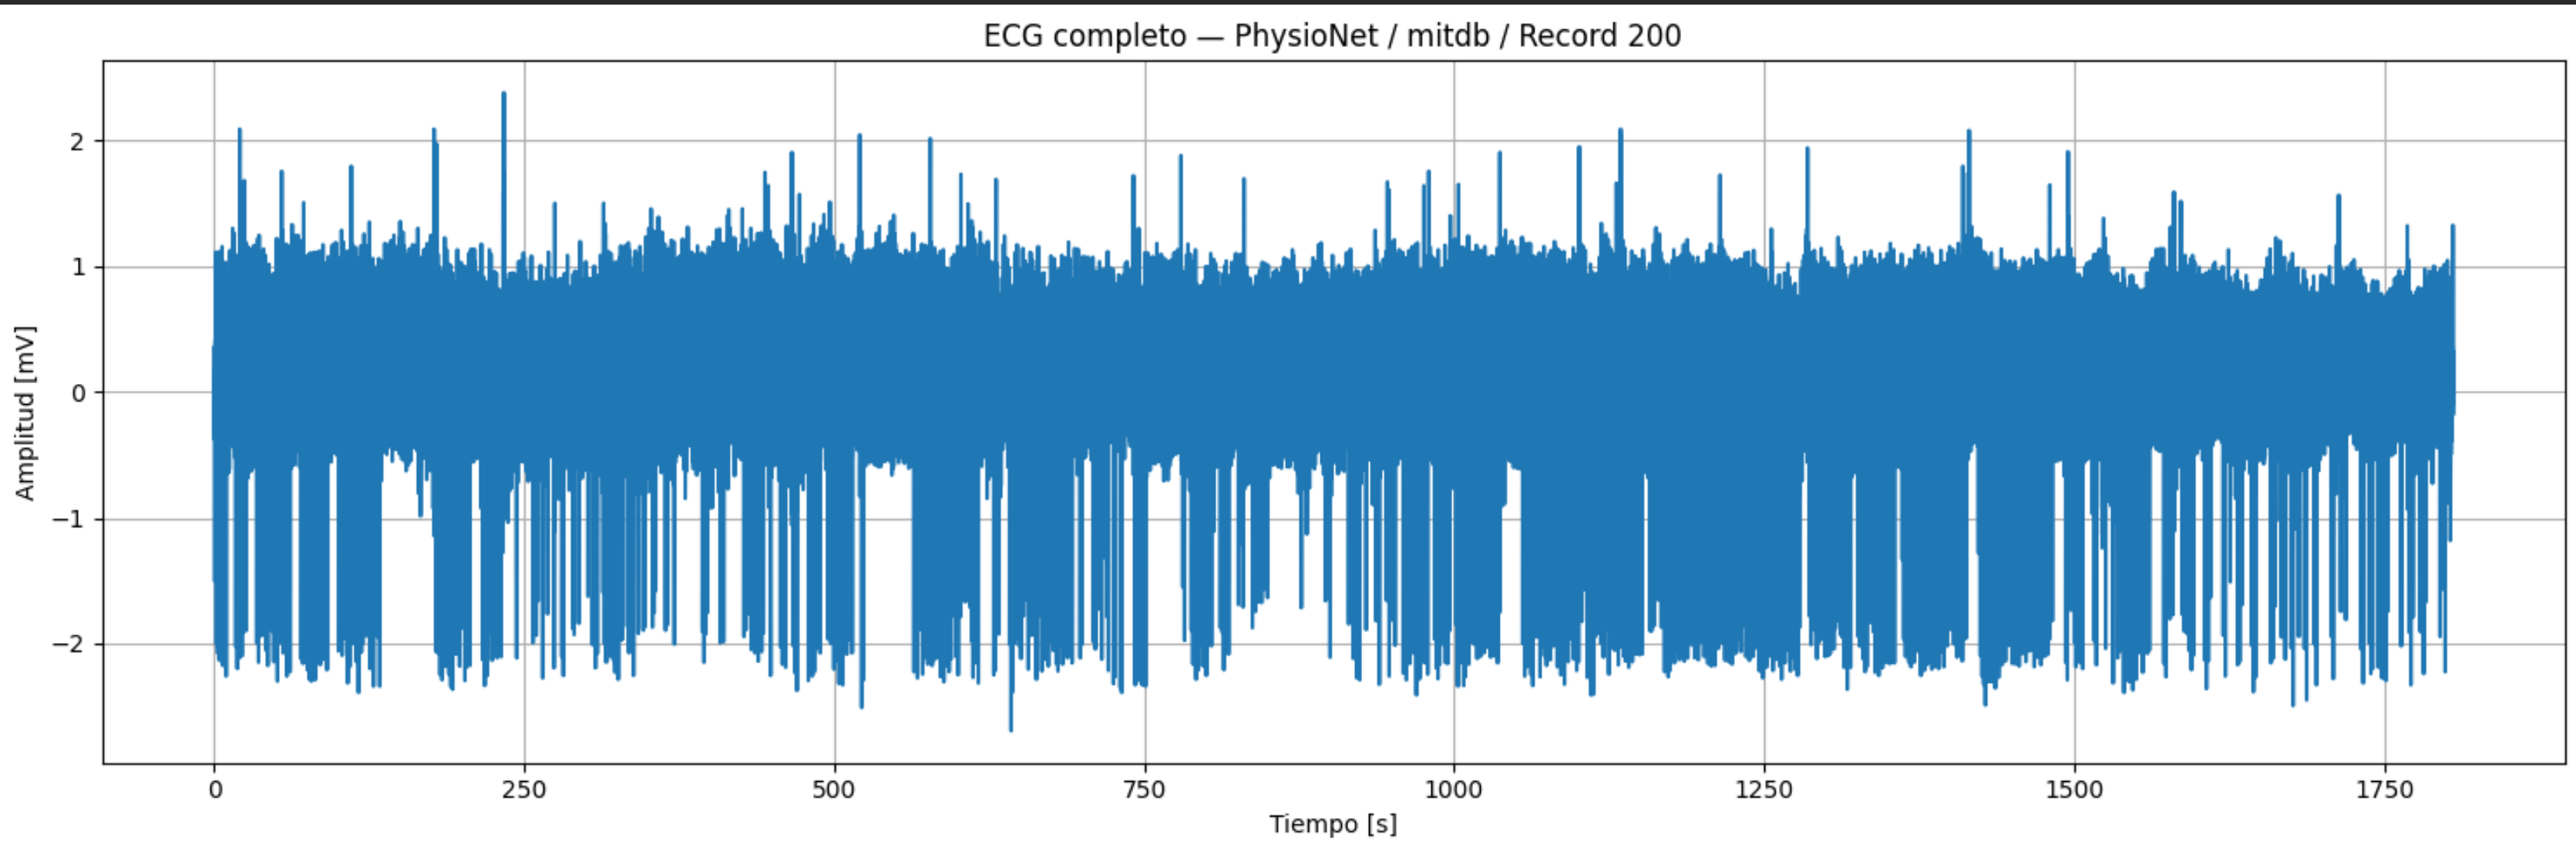

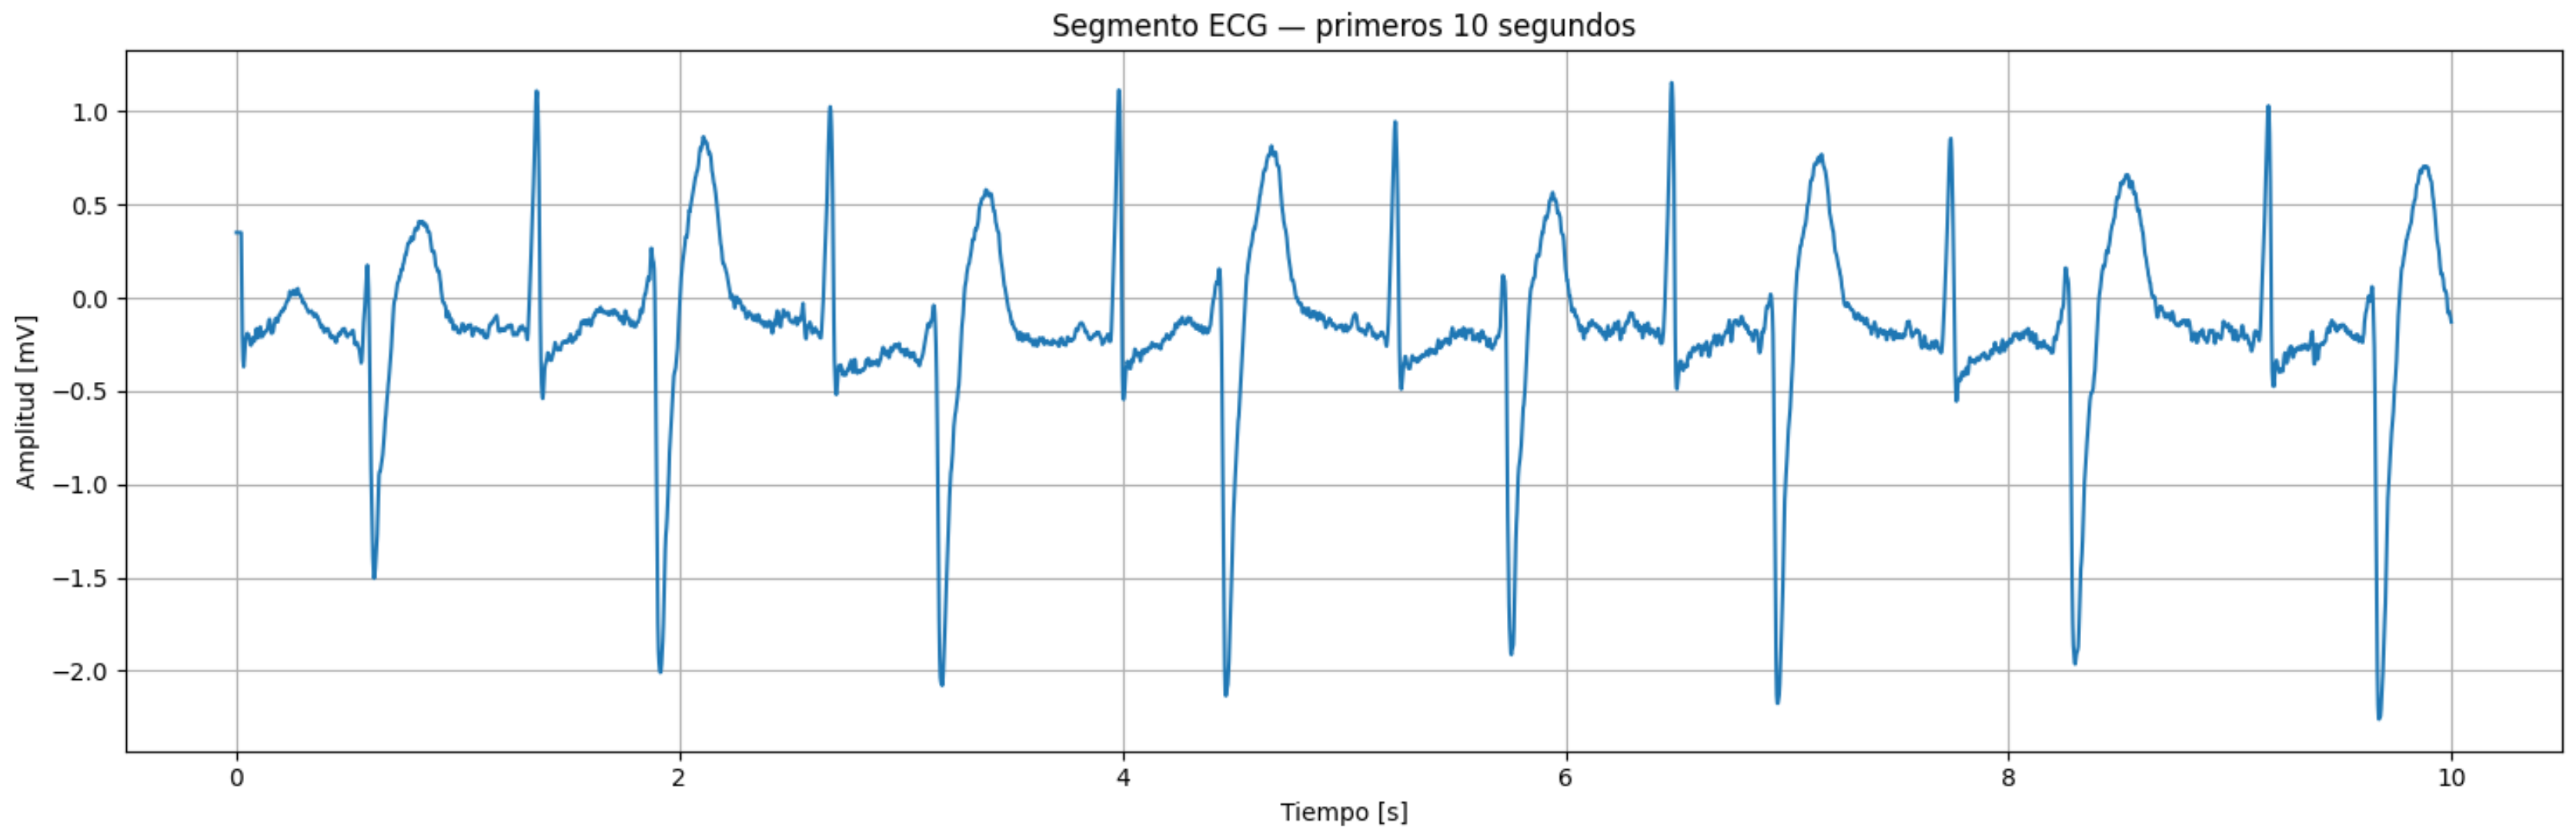

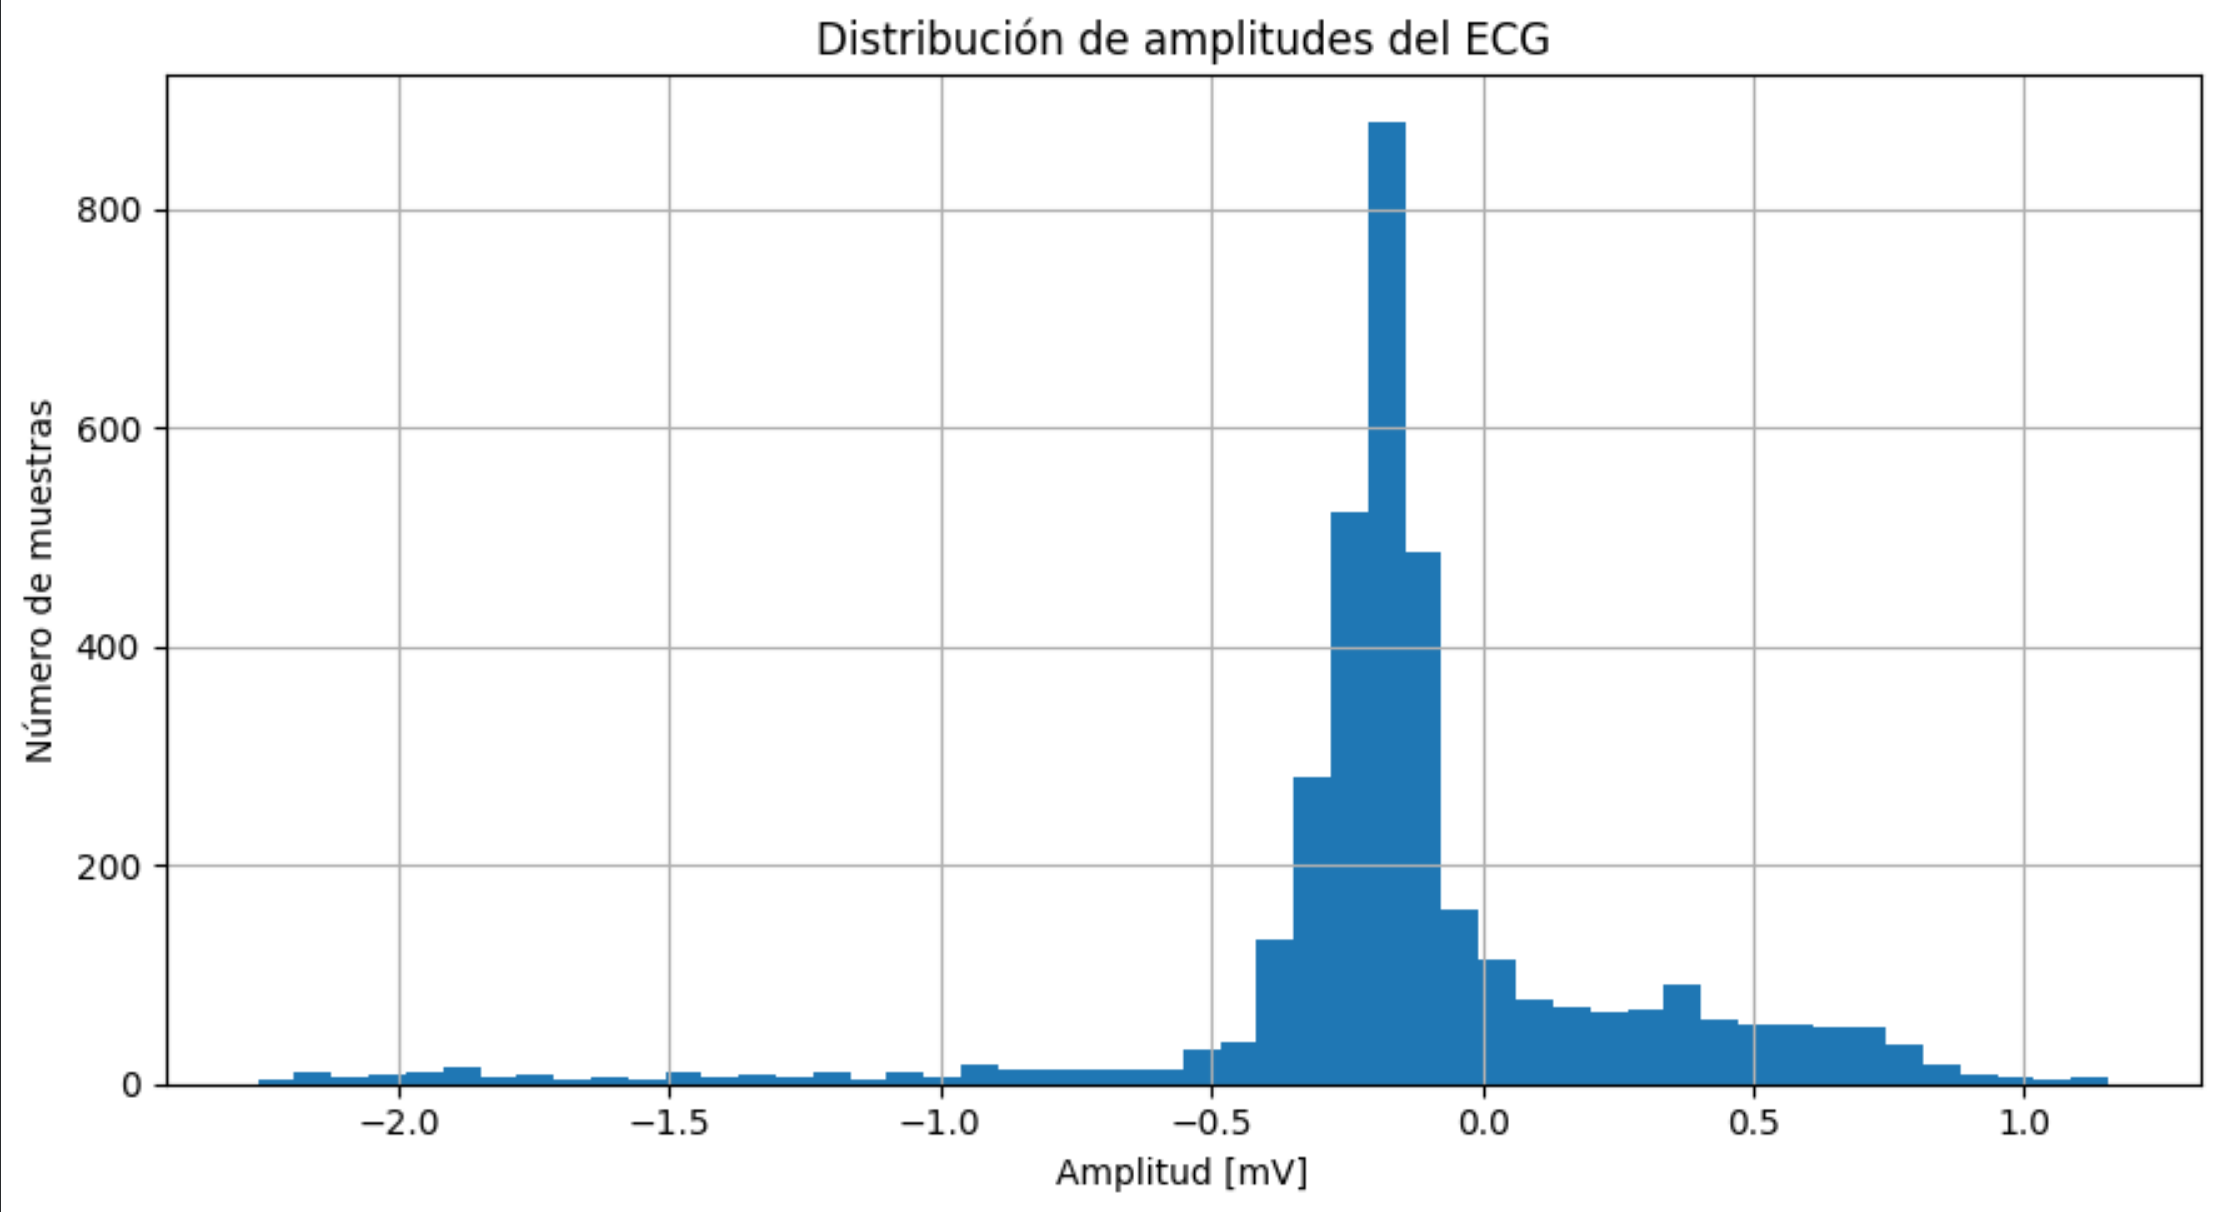

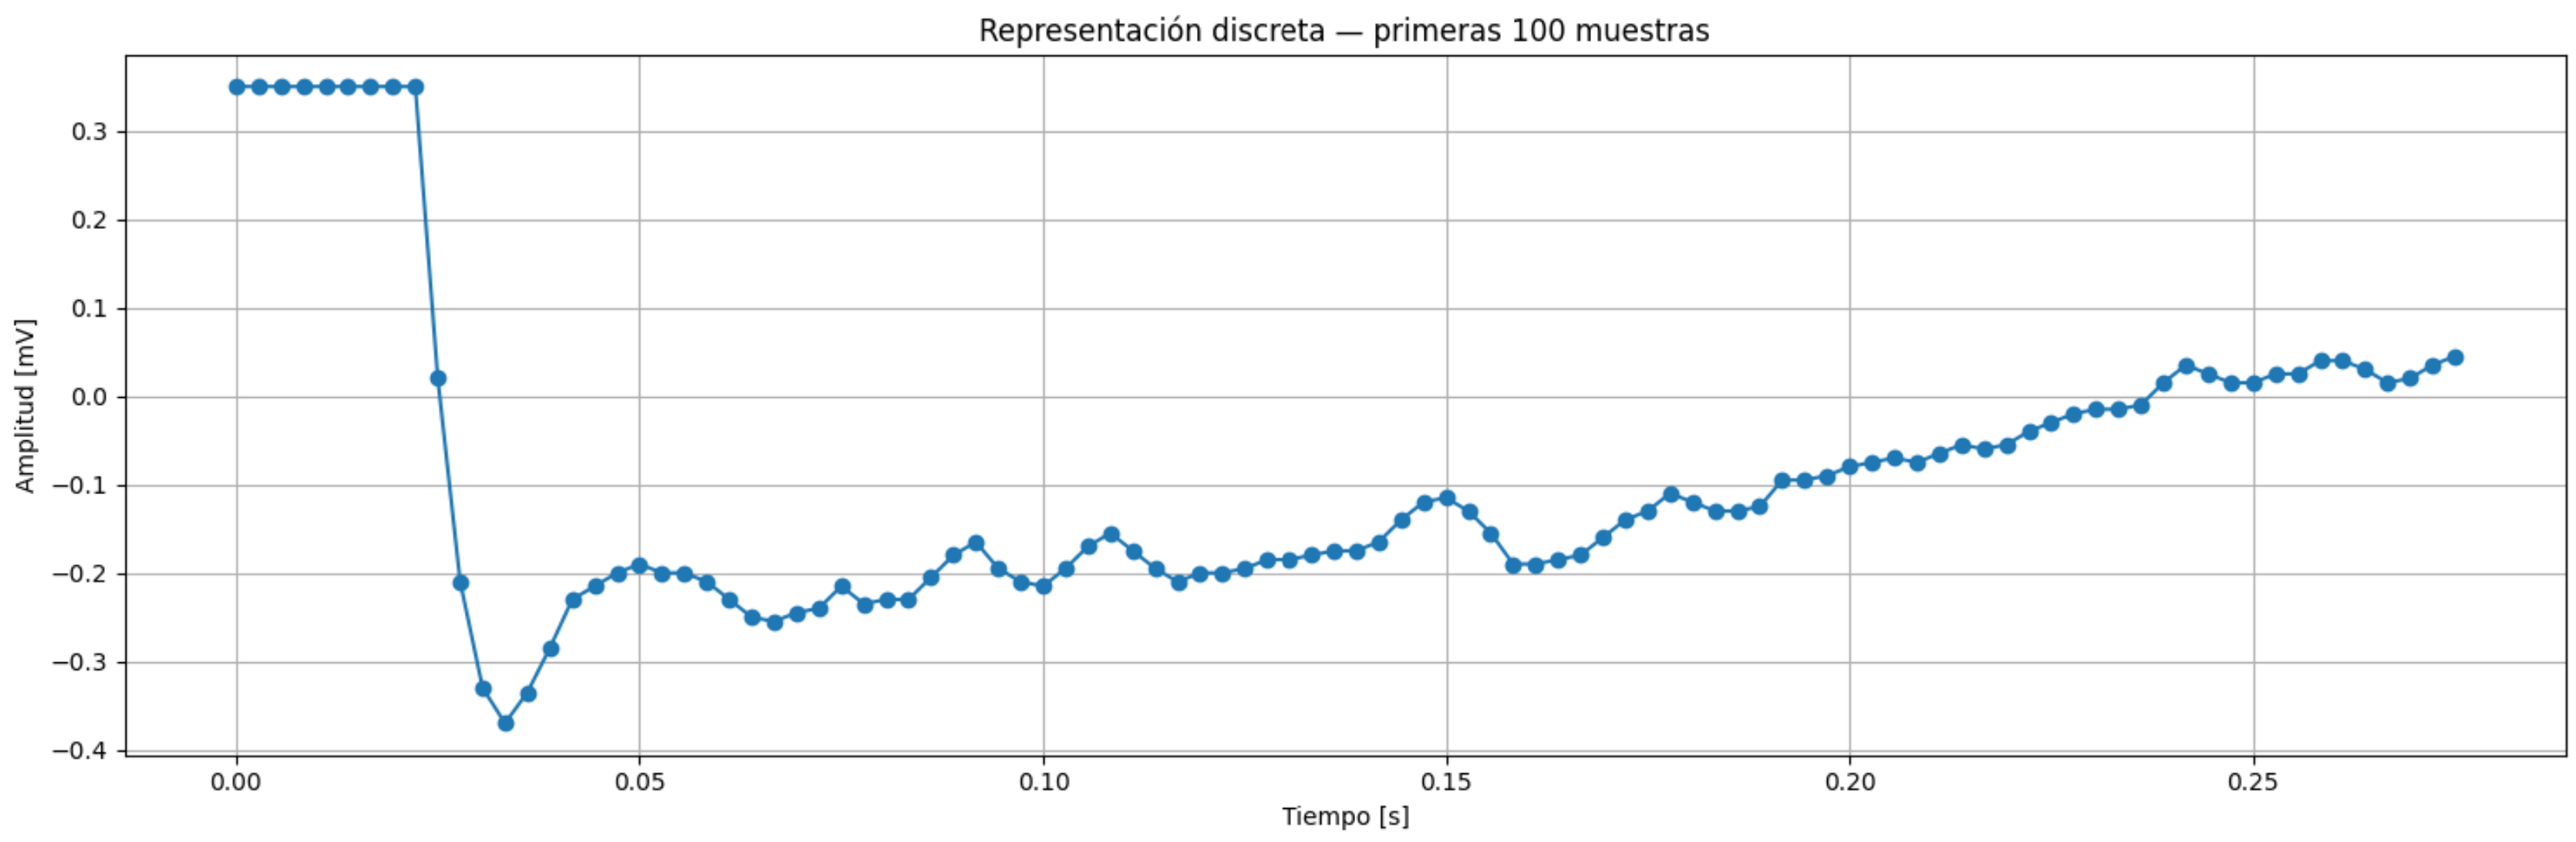

**Resolución Ejercicio 2**

Se cambia el canal, de MLII a V1

1) El nombre del nuevo canal es V5
2) Sí, ambos canales poseen la unidad de mV
3) No, la morfología de las gráficas es difernte y se explicará a continuación
4) La morfología de la primera gráfica es practicamente similar, a pesar de haber cambiado el canal. En la segunda gráfica se observa como en el primer canal, la amplitud es mayor ya que va de -0.6 a 1 aproximadamente mientras que en el segundo canal, la amplitud va de -0.4 a 1 aproximadamente. En la tercera gráfica, en el primer canal se llegan a obtener un número de muestras máximo de alrededor 800 en la amplitud de -0.4 a 0 aproximadamente, mientras que en el canal 2 se llegan a obtener un número máximo de muestas de alrededor 600 en el mismo rango de amplitud. En la cuarta gráfica, si bien ambas guardan una morfología similar, en el primer canal el rango de amplitud va de -0.4 a 0.8 mientras que en el segundo canal va de -0.3 a 0.6



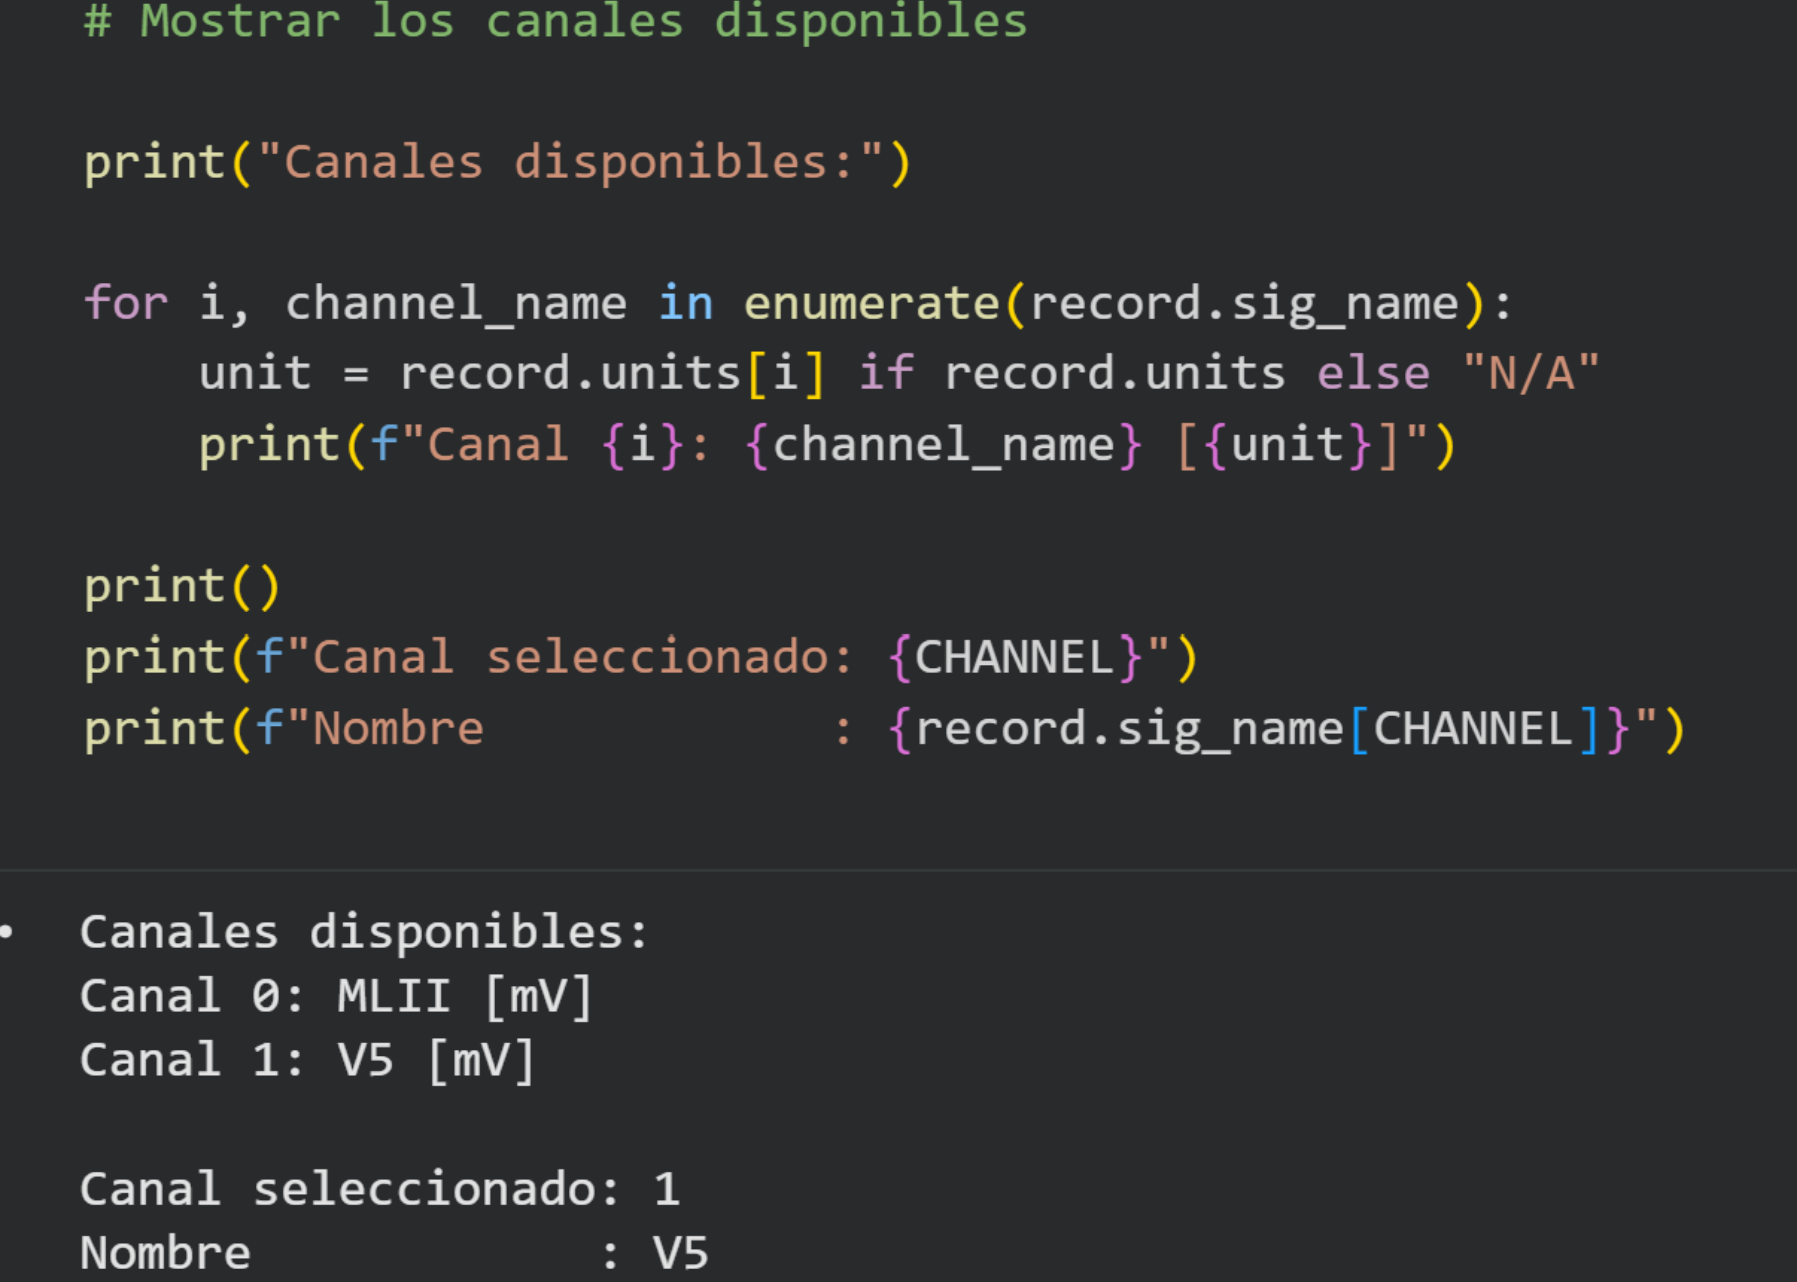

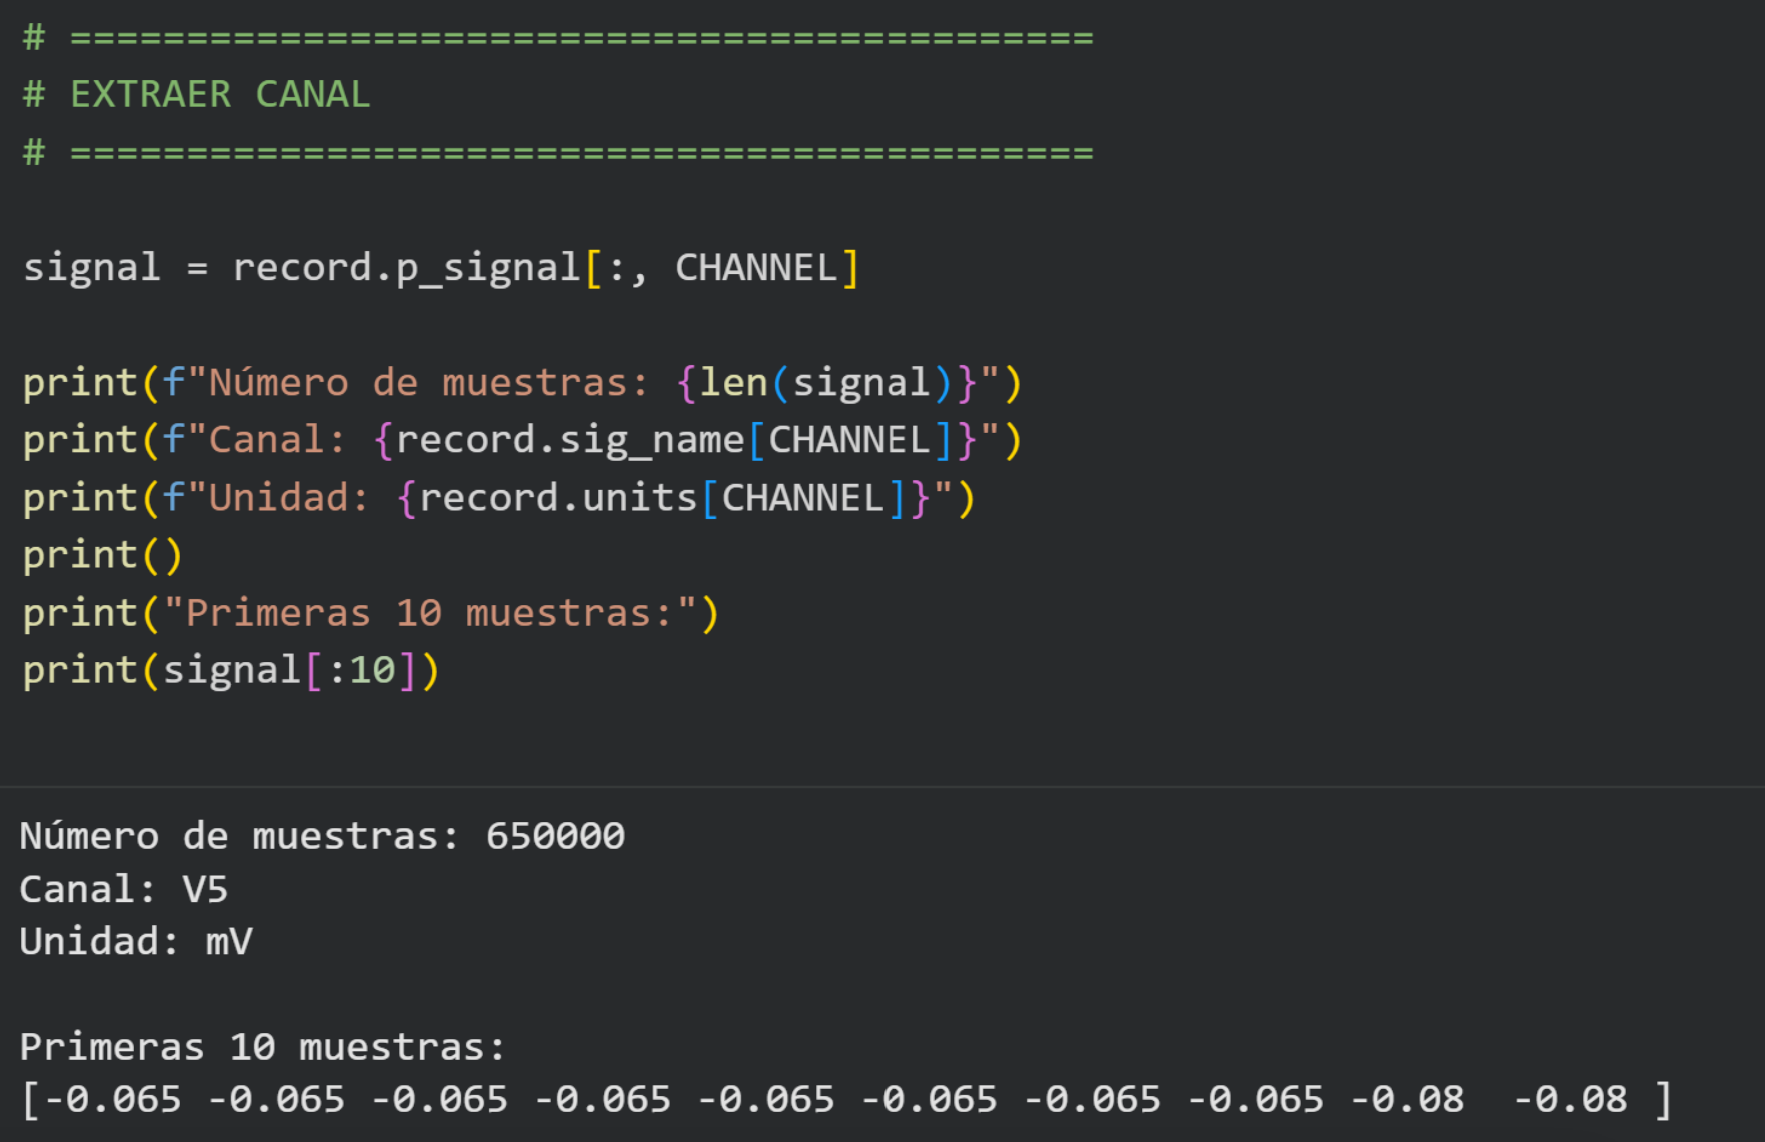

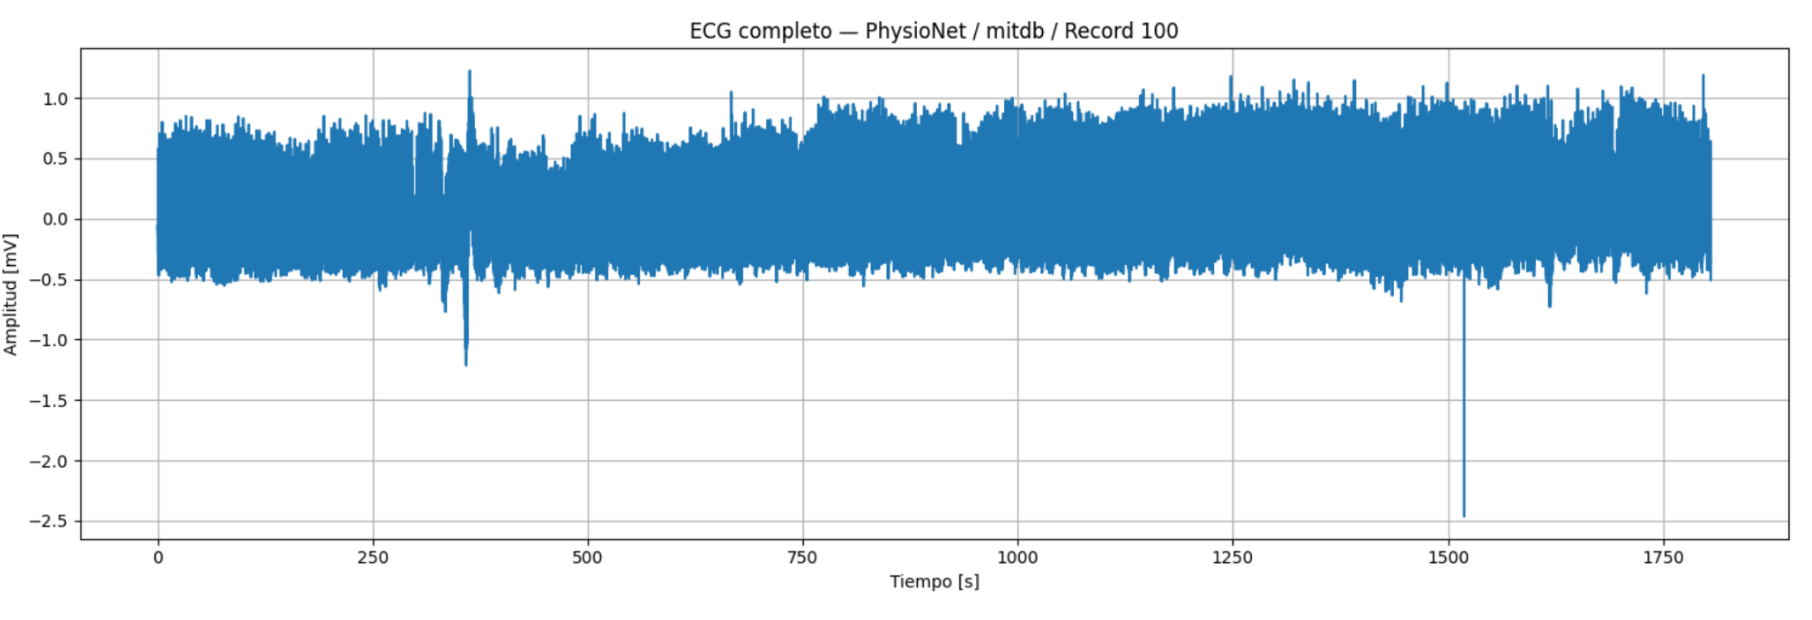

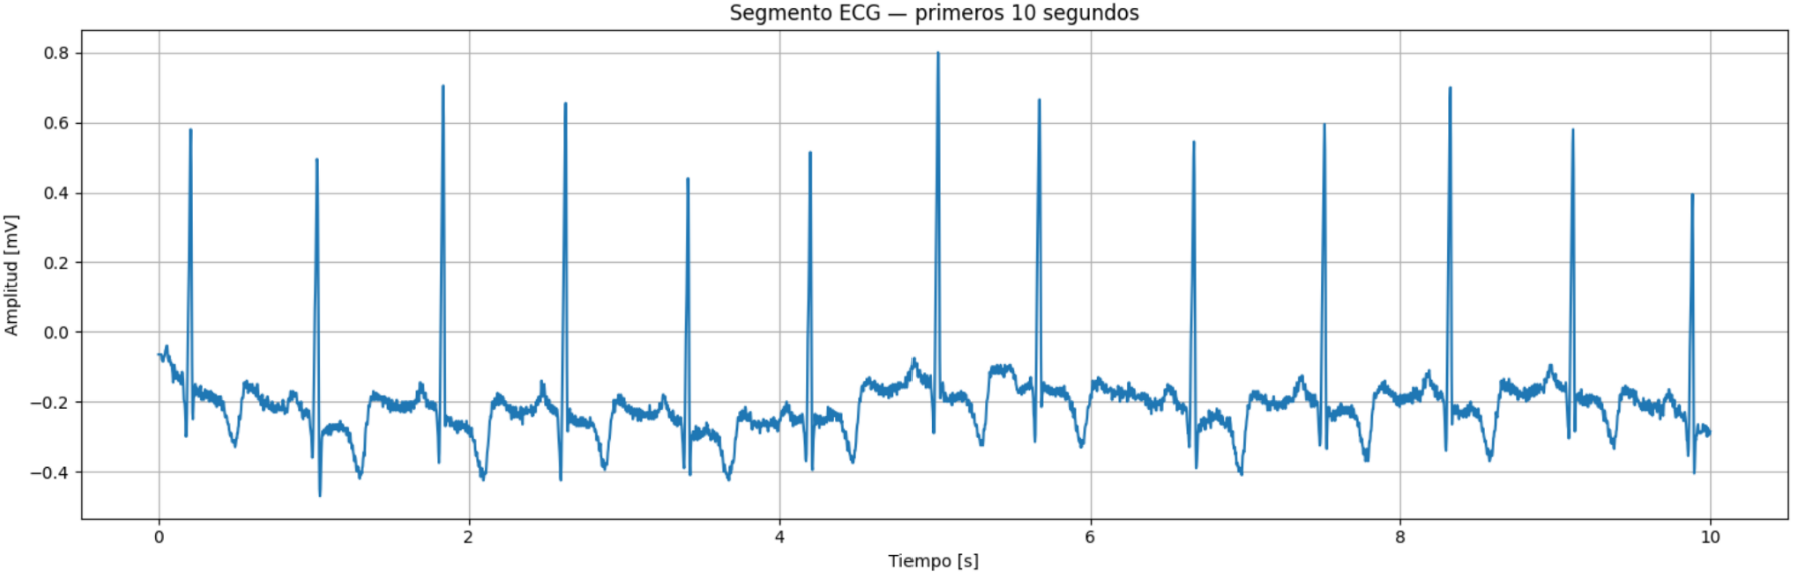

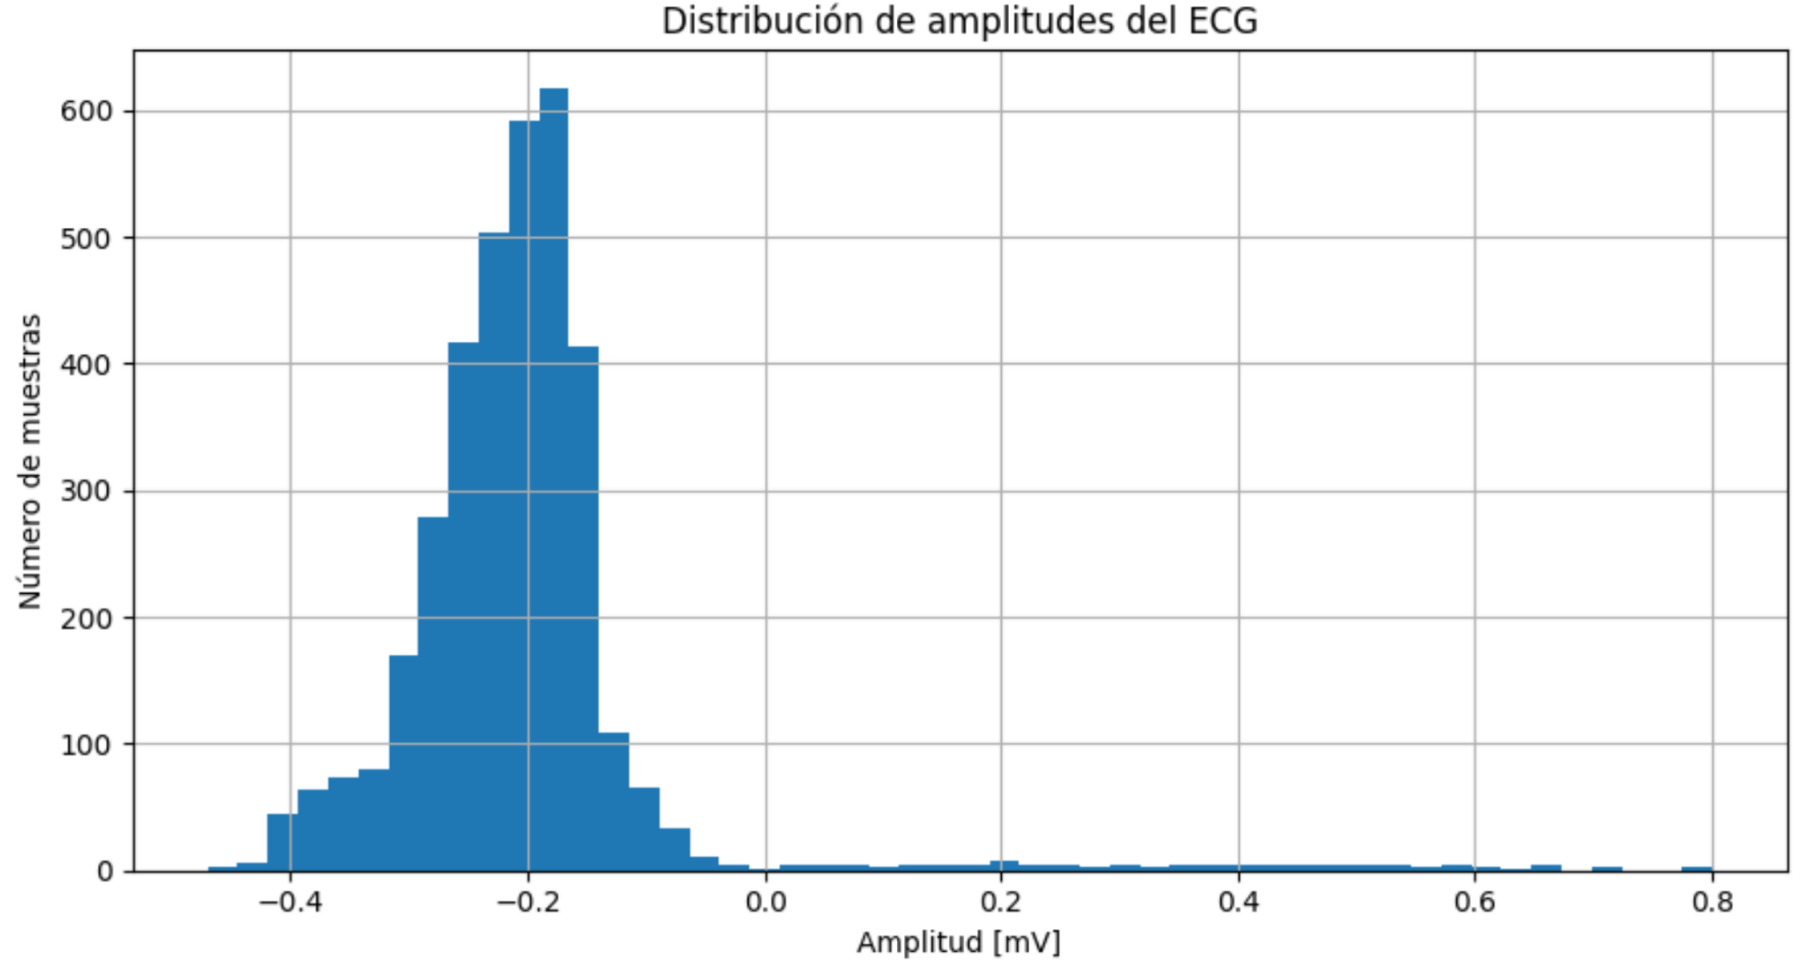

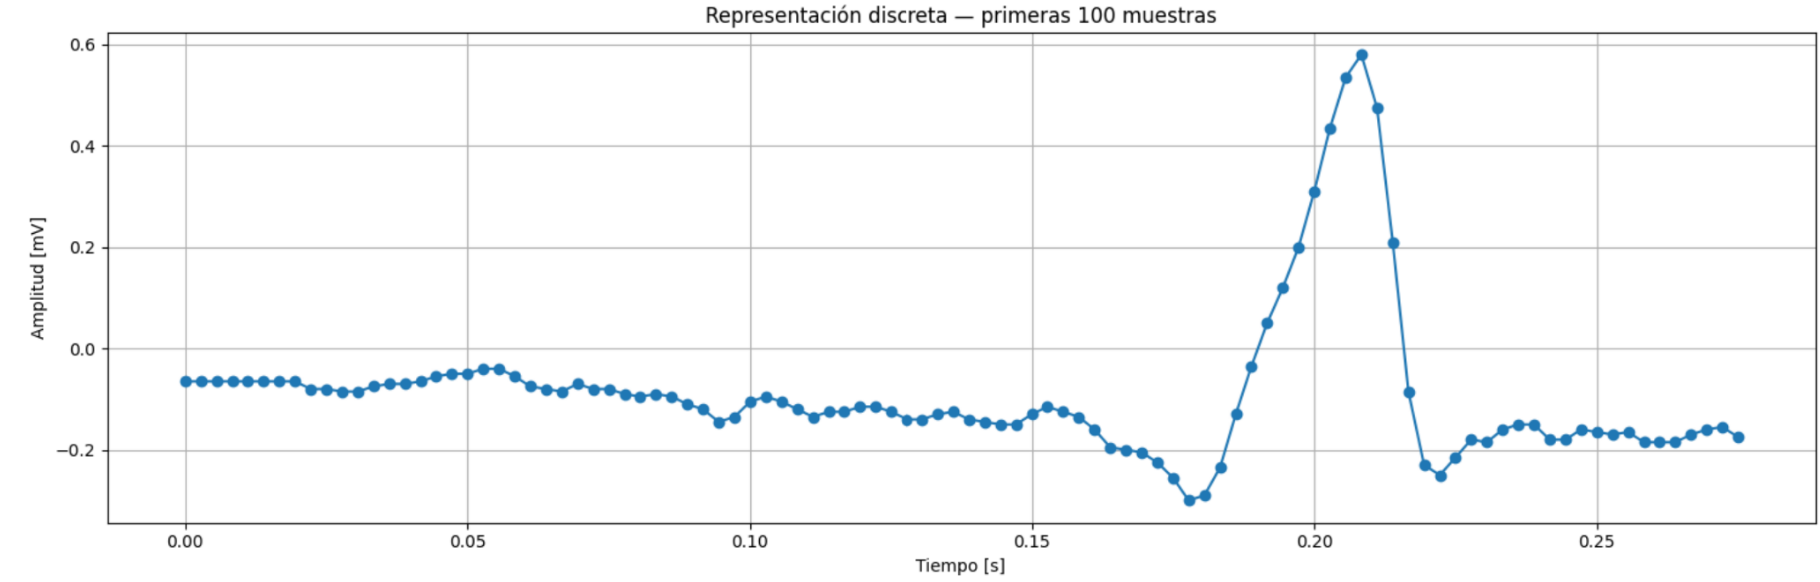

**Resolución Ejercicio 3**

Duración 5 segundos

En el caso de la primera, segunda y tercera gráfica, los resultados son los mismos. Sin embargo, en el caso de la tercera gráfica el número de muestras máximo se reduce a la mitad aproxiamdamente porque justamente se está tomando la mitad del tiempo respecto al ejercicio predeterminado.

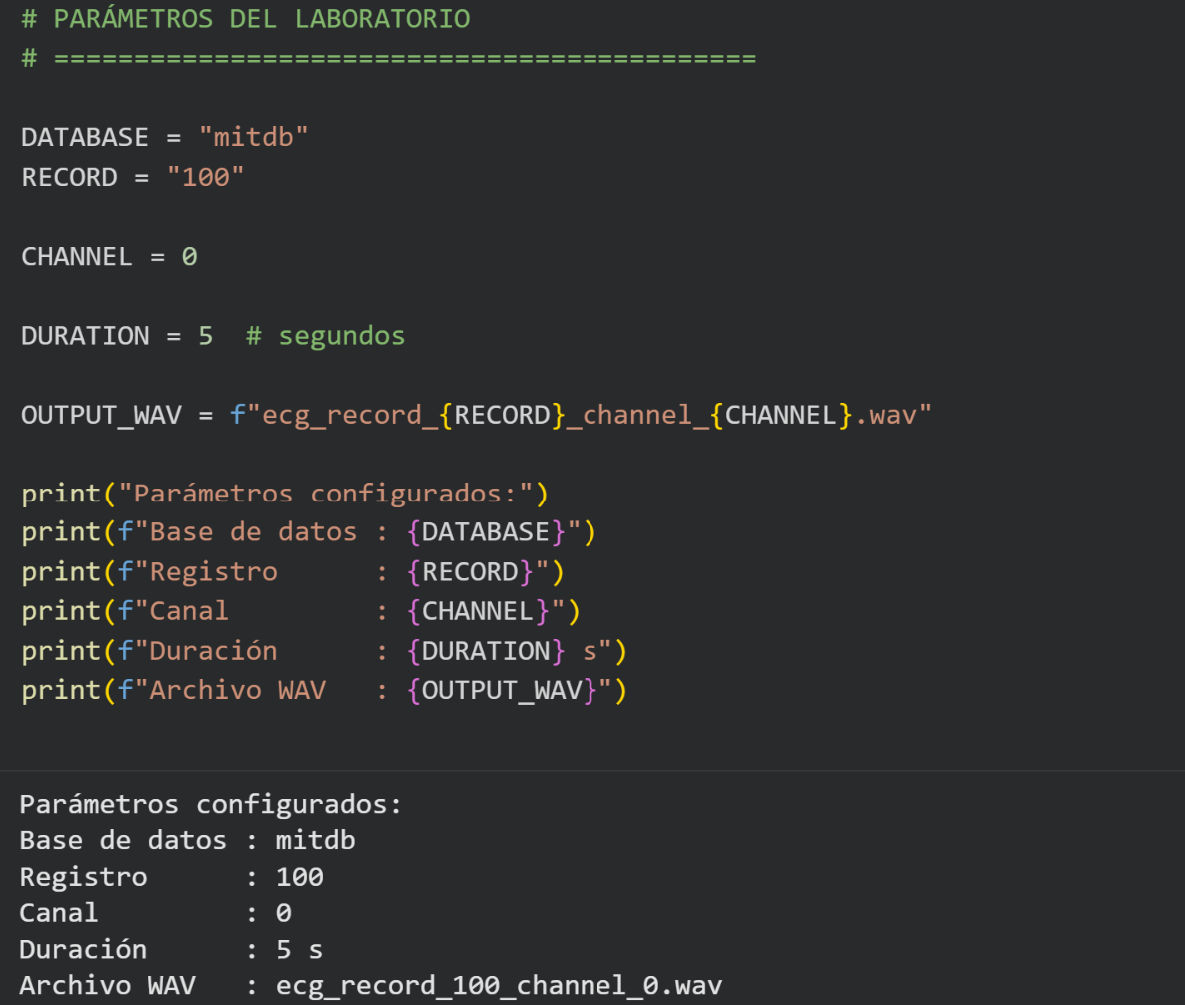

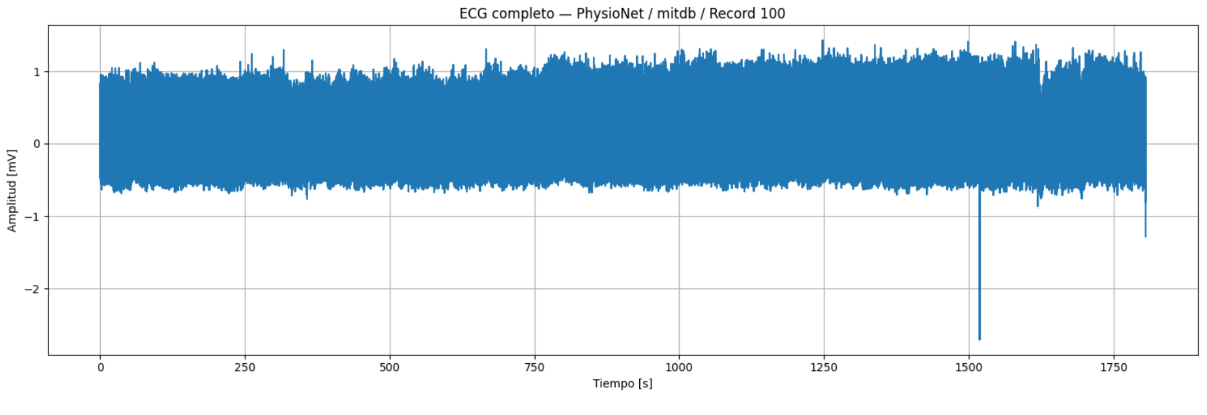

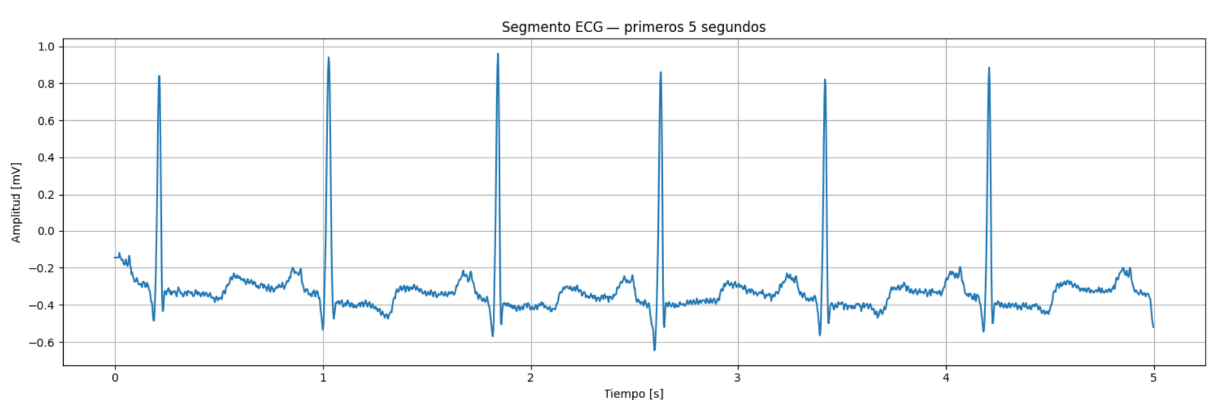

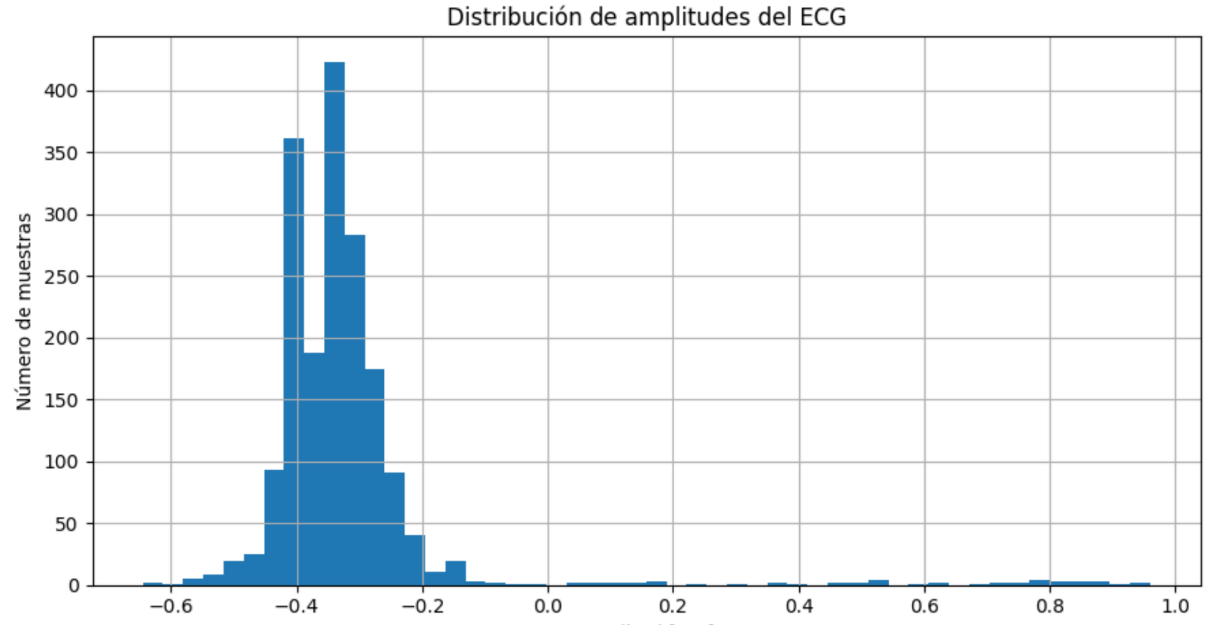

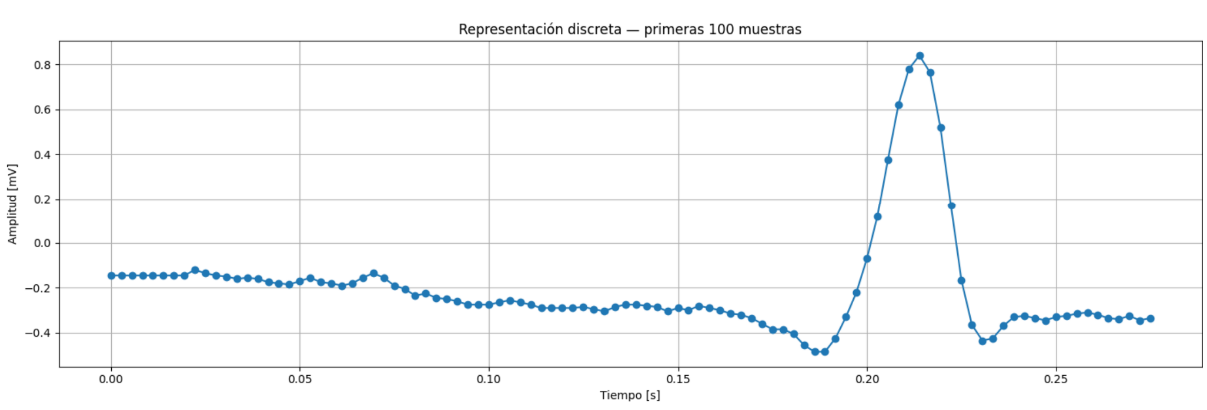

Duración 20 segundos

Como en el caso de los 5 segundos la primera, segunda y cuarta gráfica son iguales. Sin embargo, en la tercera gráfica el número de muestras máximo es el doble del valor predeterminado, justamente porque se está doblando el tiempor de duración.

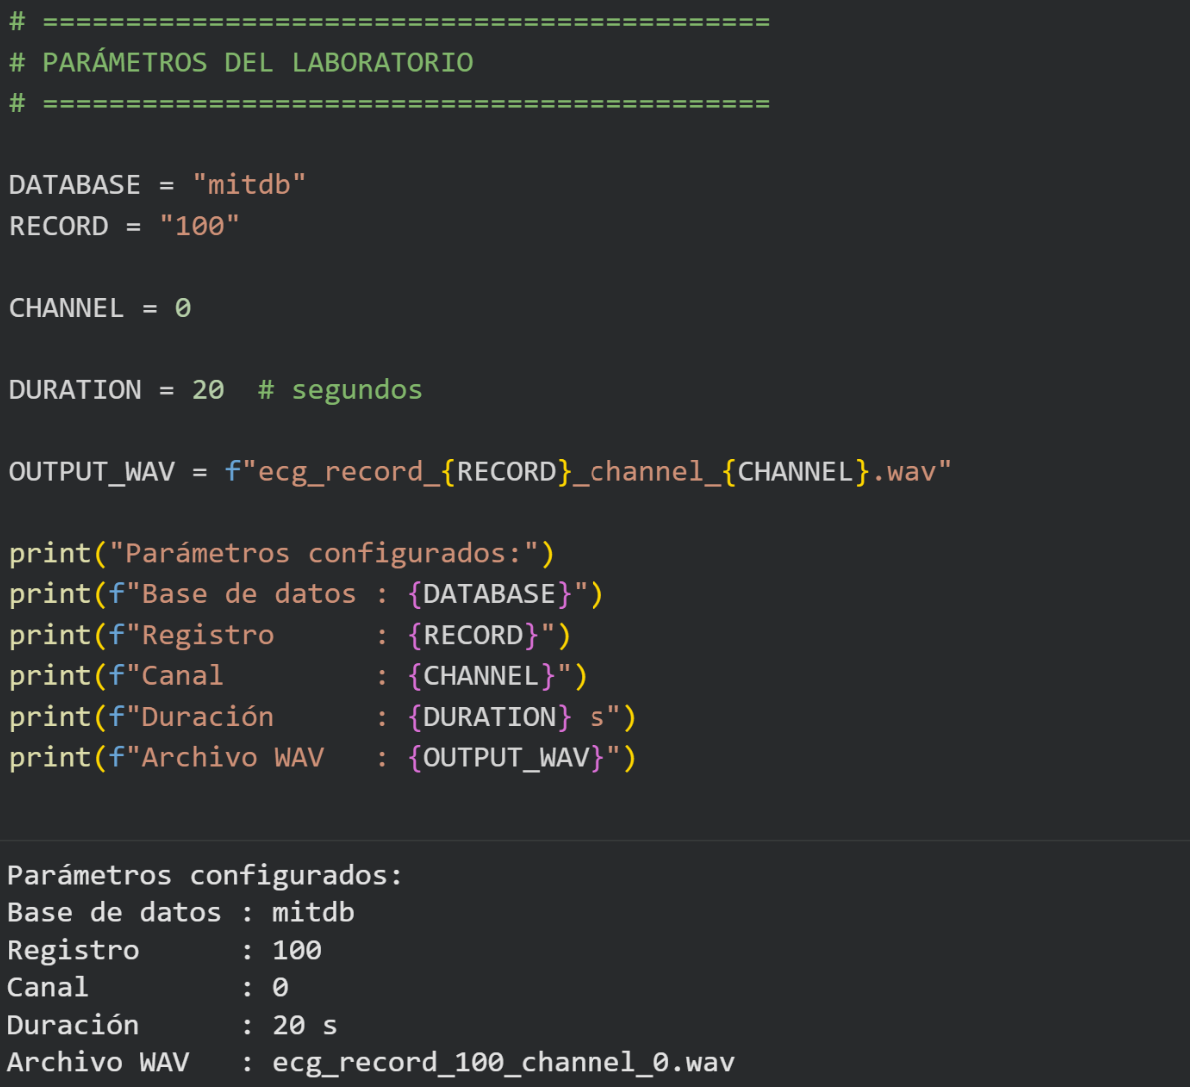

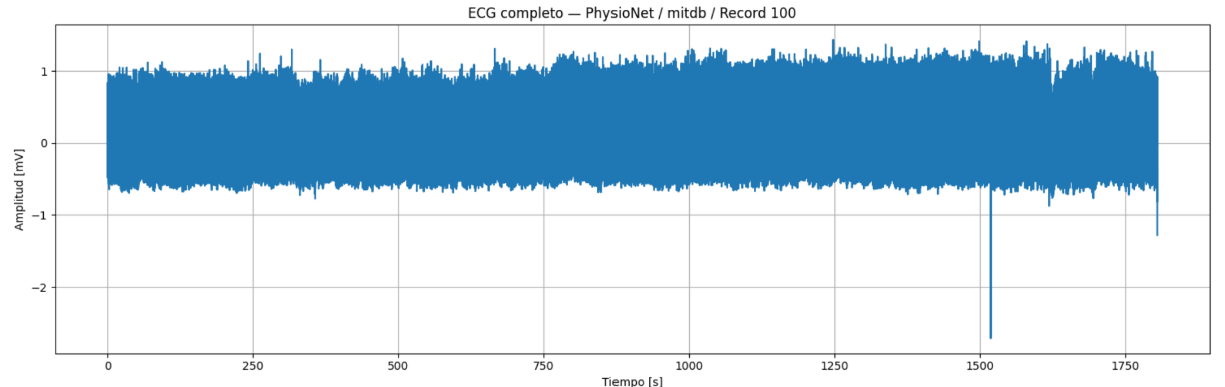

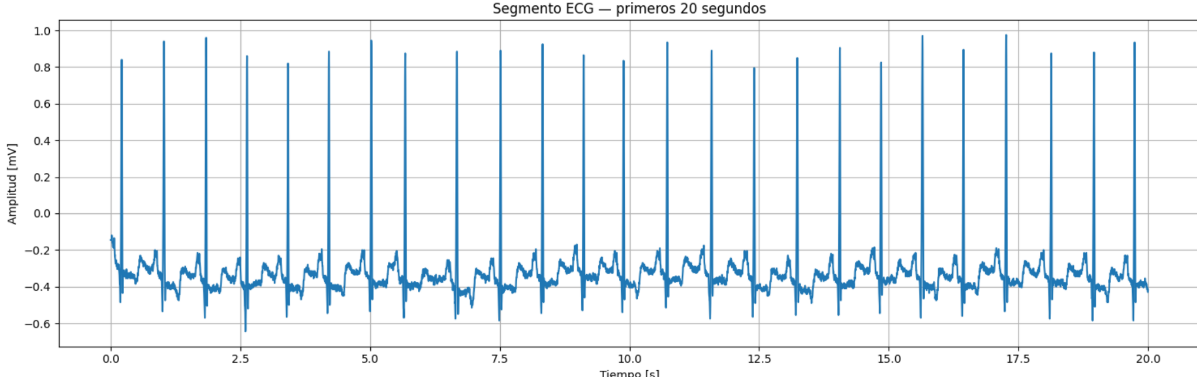

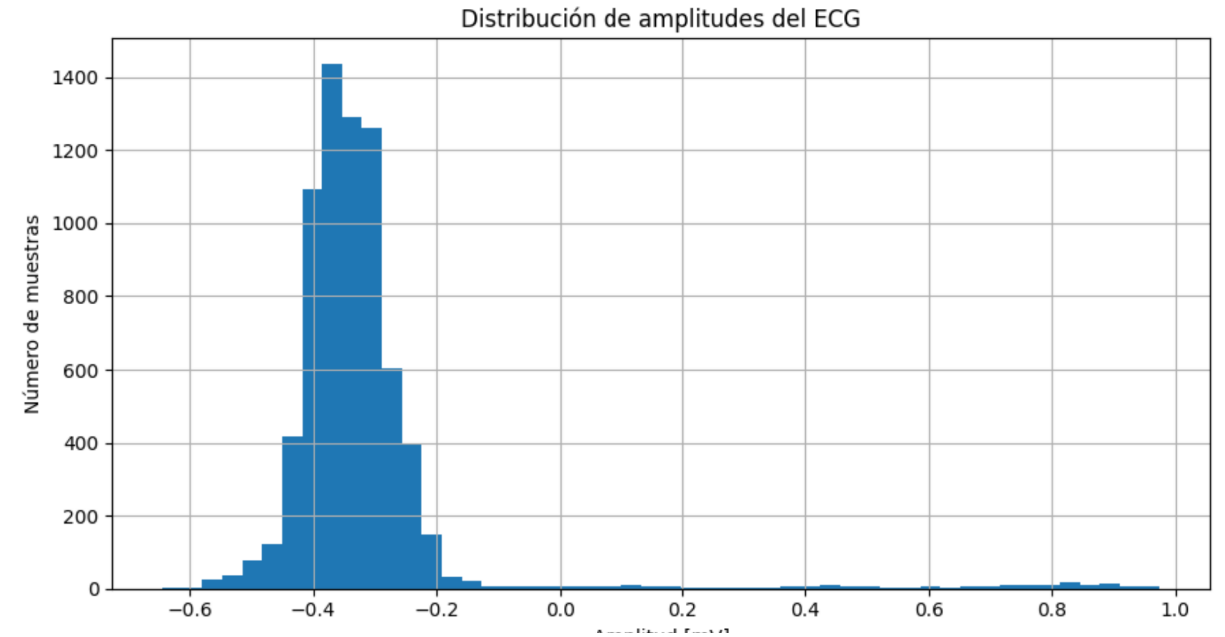

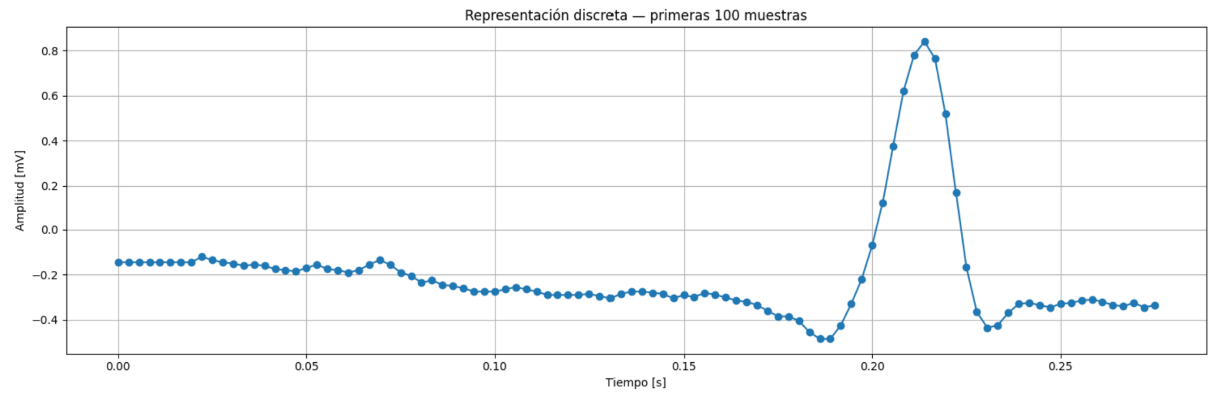

En conclusión, si se reduce la duración no habrá modificación en la visualización de la morfología se la señal, pero tampoco dejará visualizar como va variando el ritmo cardíaco u otras variables en gran medida. Por otro lado, si se aumenta la duración se podrá visualizar un mayor recorrido de como va variando el ritmo cardíaco u otras variables pero se comprimirá la señal, lo cual dificultaría ver detalles.


## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a)

Calcule el periodo de muestreo:

\[
T_s = \frac{1}{f_s}
\]



### b)

¿Cuántas muestras existen en 5 segundos?

### c)

¿Cuántas muestras existen en 10 segundos?

### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


**Resolución Ejercicio 4**

fs = 360Hz

a) Periodo de muestreo

- T = 1/fs = 1/360 = 0.0027778s

b) Muestras en 5 segundos

- N = fs*T = 360(5) = 1800 muestras

c) Muestras en 10 segundos

- N = fs*T = 360(10) = 3600 muestras

d) Si se reduce la frecuencia de muestreo, se obtendrían menos muestras por segundo, por lo cual se perdería resolución temporal. Si se analizara el caso de que se redujera significativamente, la visualización se la señal se vería afectada por el posible aliasing


Resolución Ejercicio 5

Para el cálculo de esos valores, se efectuara una linea de código para facilitar la resolución

- Media: Valor promedio de amplitud de las muestras del segmento seleccionado

- Desviación estandar: Medida de la dispersión de los valores respecto a la media

- Máximo: Valor de amplitud más alto del segmento seleccionado

- Mínimo: Valor de amplitud más bajo del segmento seleccionado

- Rango: Diferencia entre el máximo y el mínimo

In [ ]:
mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

range_value = max_value - min_value

print(f"Media: {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Máximo: {max_value:.4f}")
print(f"Mínimo: {min_value:.4f}")
print(f"Rango: {range_value:.4f}")

Media: -0.3199
Desviación estándar: 0.1702
Máximo: 0.9600
Mínimo: -0.6450
Rango: 1.6050



# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?

### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?

### 3.
¿Qué representa `fs`?

### 4.
¿Qué representa `CHANNEL`?

### 5.
¿Qué representa `record.p_signal`?

### 6.
¿Por qué necesitamos construir un eje temporal?

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?

### 10.
¿Qué dificultades encontró durante el laboratorio?


Resolución de preguntas conceptuales

1) PhysioNet es una plataforma de libre acceso que almacena bases de datos de señales y datos fisiológicos reales. En el caso de este laboratorio, se utiliza para obtener registros electrocardiográficos

2) DATABASE registra la base de datos y RECORD identifica un registro específico dentro de esta misma

3) fs represent ala frecuencia de muestreo. Esta medida represetna la cantidad de muestras que se adquieren por segundo

4) CHANNEL representa el canal específico de una señal.

5) record.p_signal representa las muestras de la señal seleccionada del registro

6) Es necesario construir un eje temporal porque de forma predeterminada, las muestras están identificadas por índices. Al contruir un eje temporal, se puede obtener la información del momento de adquisición de cada muestra.

7) Una señal continua está definida para cualquier instante de tiempo. Por otro lado, una señal discreta está definida para específicos instantes de muestreo.

8) Debido a que el WAV es solo un medio de almacenamiento de las muestras ECG en el formato audio. No se pueden obtener ciertos parámetros ya que en si no se puede representar una señal fisiológica en su totalidad, solo en audio

9) La principal ventaja de trabajar con señales biomédicas en vez de señales estéticas, es que se pueden presenciar eventos reales que suceden debido a las señales fisiológicas, lo cual permite acercarse bastante a una situación real

10) Unas de las principales dificultades del laboratorio fue entender como se usa DATABASE, RECORD, además de como convertir a un archivo WAV.


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


In [ ]:
# Seleccionar RECORD 230

DATABASE = "mitdb"
RECORD = "230"
CHANNEL = 0
DURATION = 10
OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

record = wfdb.rdrecord(RECORD, pn_dir=DATABASE)

In [ ]:
# Identificar canales

print("Frecuencia de muestreo:", record.fs)
print("Número de muestras:", record.sig_len)
print("Número de canales:", record.n_sig)
print("Canales:", record.sig_name)

Frecuencia de muestreo: 360
Número de muestras: 650000
Número de canales: 2
Canales: ['MLII', 'V1']


In [ ]:
# Seleccionar canal ECG

signal = record.p_signal[:, CHANNEL]
fs = record.fs

t = np.arange(len(signal)) / fs

In [ ]:
# Analizar 10 segundos

DURATION = 10

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]


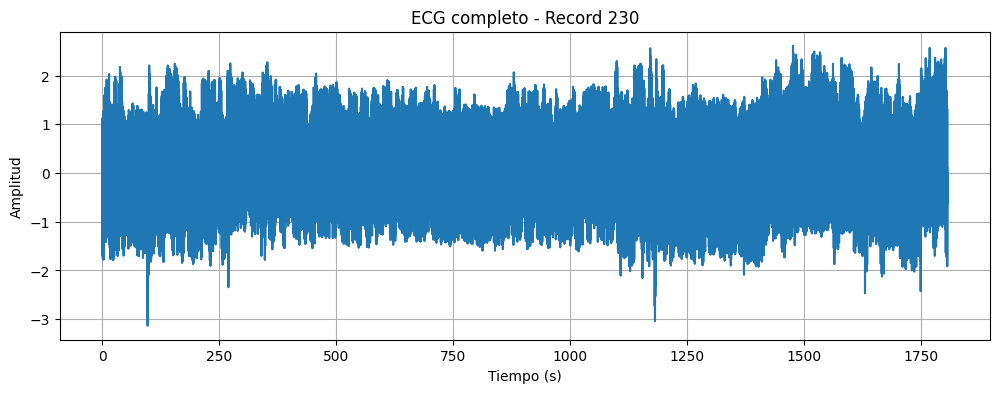

In [ ]:
# Gráfica ECG

plt.figure(figsize=(12, 4))
plt.plot(t, signal)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title(f"ECG completo - Record {RECORD}")
plt.grid()
plt.show()

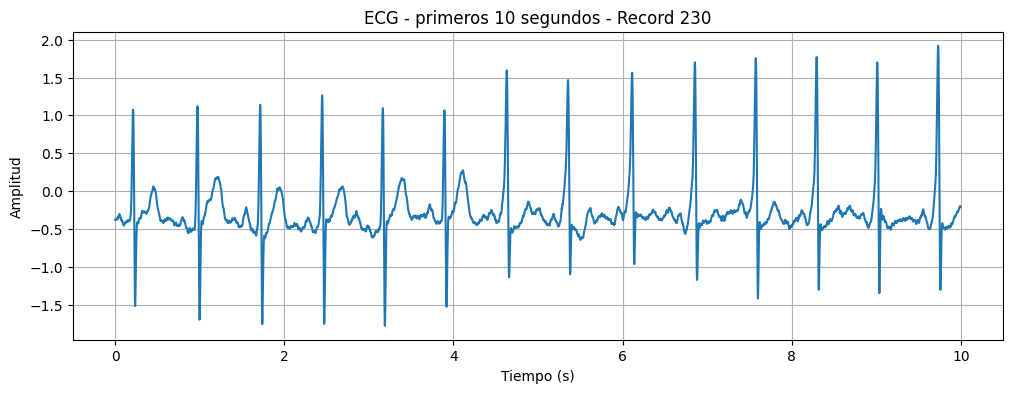

In [ ]:
# ECG 10 segundo

plt.figure(figsize=(12, 4))
plt.plot(t_segment, signal_segment)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title(f"ECG - primeros {DURATION} segundos - Record {RECORD}")
plt.grid()
plt.show()



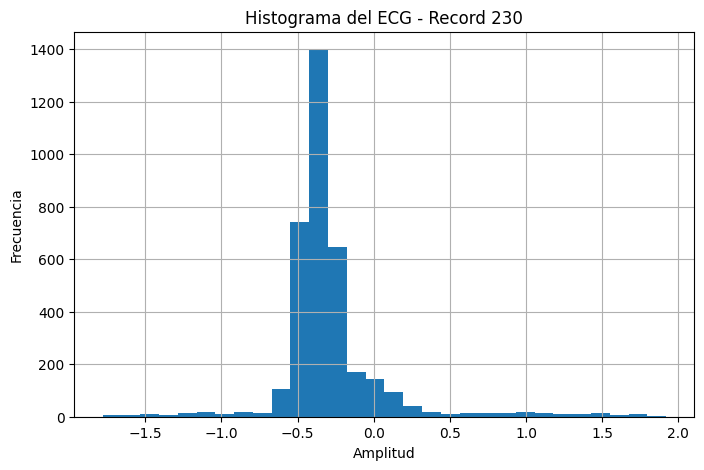

In [ ]:
# Histograma

plt.figure(figsize=(8, 5))
plt.hist(signal_segment, bins=30)
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.title(f"Histograma del ECG - Record {RECORD}")
plt.grid()
plt.show()

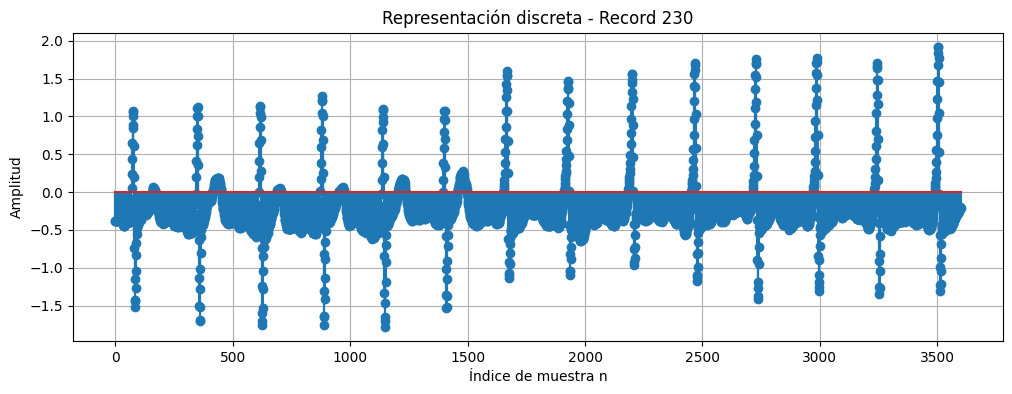

In [ ]:
# Representación discreta

n = np.arange(len(signal_segment))

plt.figure(figsize=(12, 4))
plt.stem(n, signal_segment)
plt.xlabel("Índice de muestra n")
plt.ylabel("Amplitud")
plt.title(f"Representación discreta - Record {RECORD}")
plt.grid()
plt.show()

In [ ]:
# Estadísticas

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("Media:", mean_value)
print("Desviación estándar:", std_value)
print("Mínimo:", min_value)
print("Máximo:", max_value)

Media: -0.2890069444444444
Desviación estándar: 0.36265692956689216
Mínimo: -1.78
Máximo: 1.92


In [ ]:
# Archivo WAV

ecg_for_wav = signal_segment.astype(float).copy()

ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

max_abs = np.max(np.abs(ecg_for_wav))

ecg_normalized = ecg_for_wav / max_abs

ecg_int16 = np.int16(ecg_normalized * 32767)

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print("Archivo WAV generado:")
print(OUTPUT_WAV)

Archivo WAV generado:
ecg_record_230_channel_0.wav


Informe

1) Identificación de base de datos

- La base de datos es "mitdb" o MIT-BIH Arrhythmia Database

2) Identificación de registro

- El registro utilizado es el 230

3) Frecuencia de muestreo

- Como se muestra en el código, la frecuencia de muestreo es 360

4) Canal seleccionado

- Se selecciona el primer canal, como se puede observar es el MLII



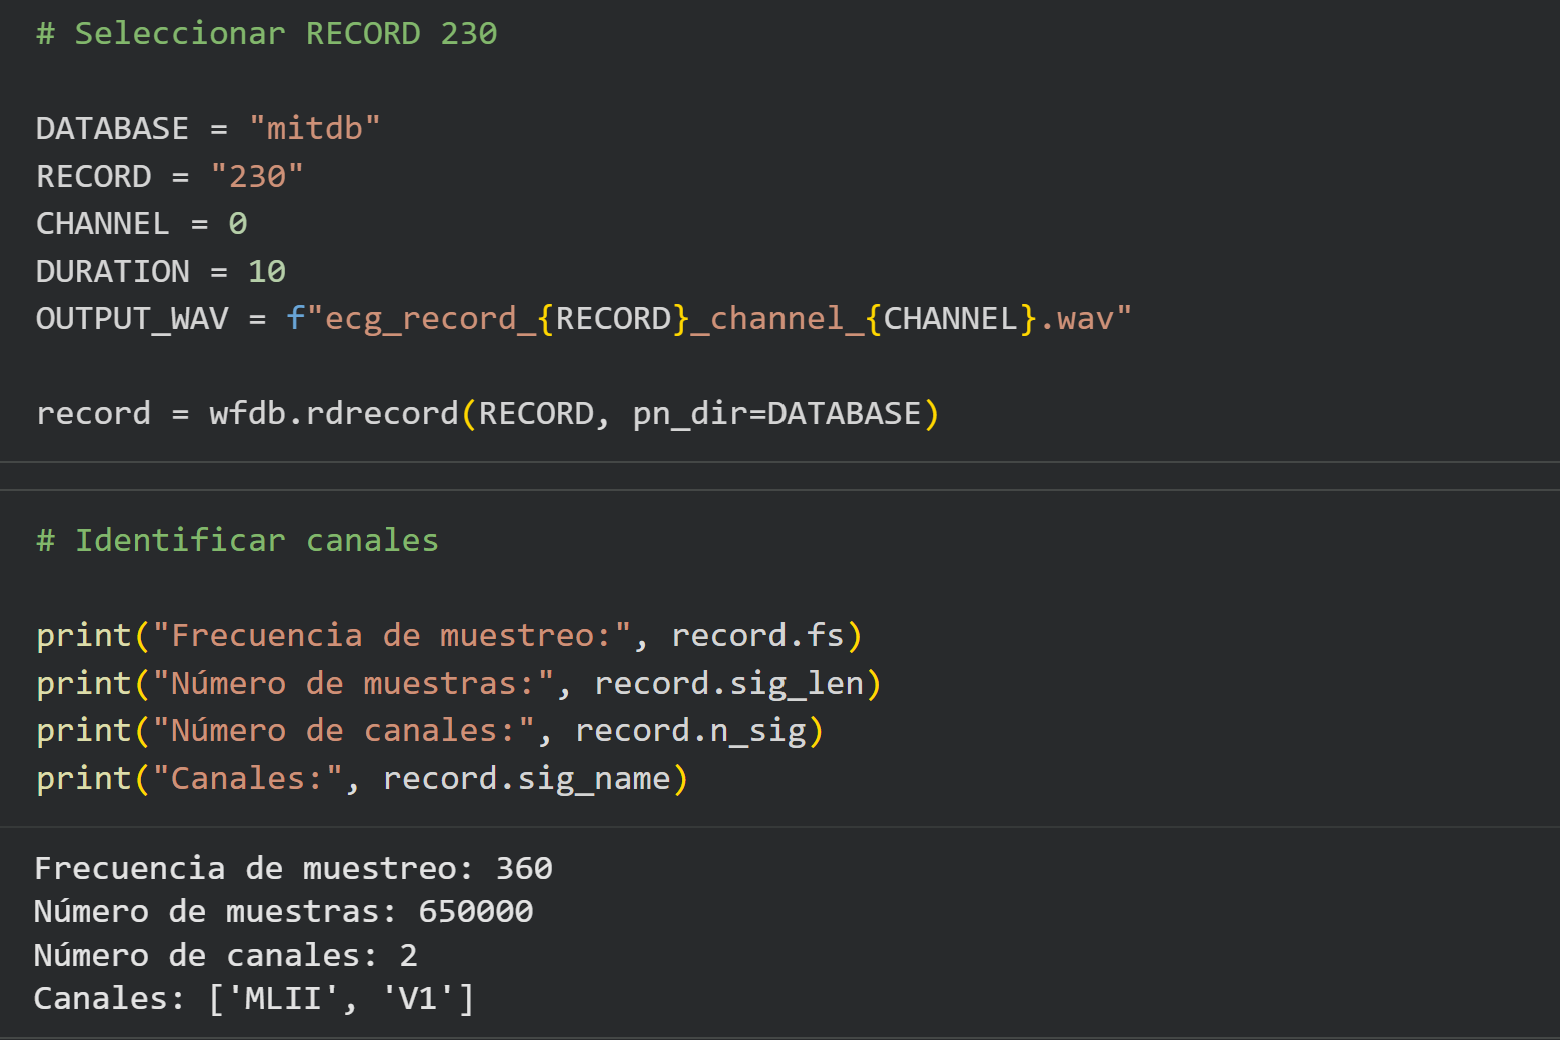

5) Duración analizada

- Se analizan 10 segundos

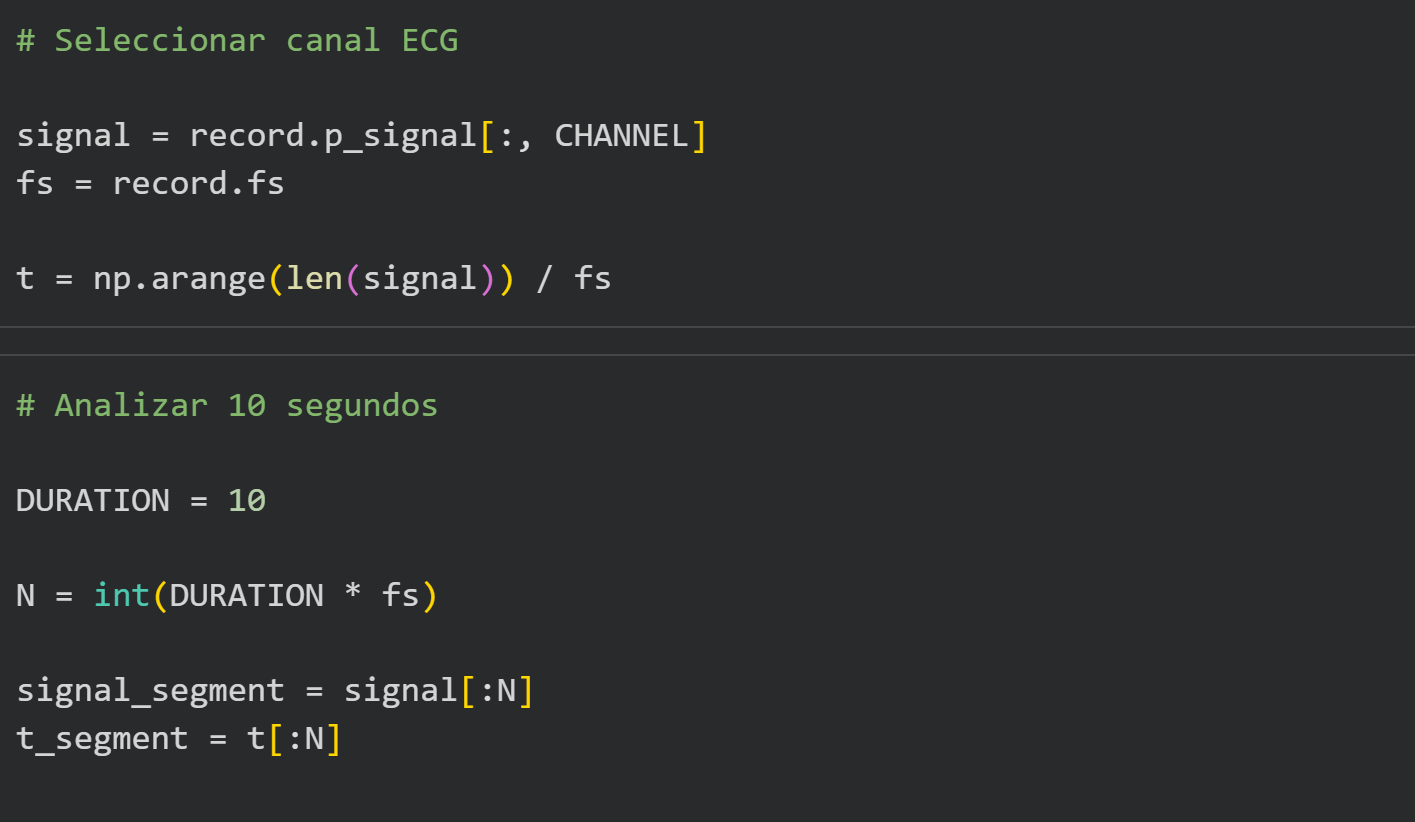

6.1) Primera gráfica - ECG

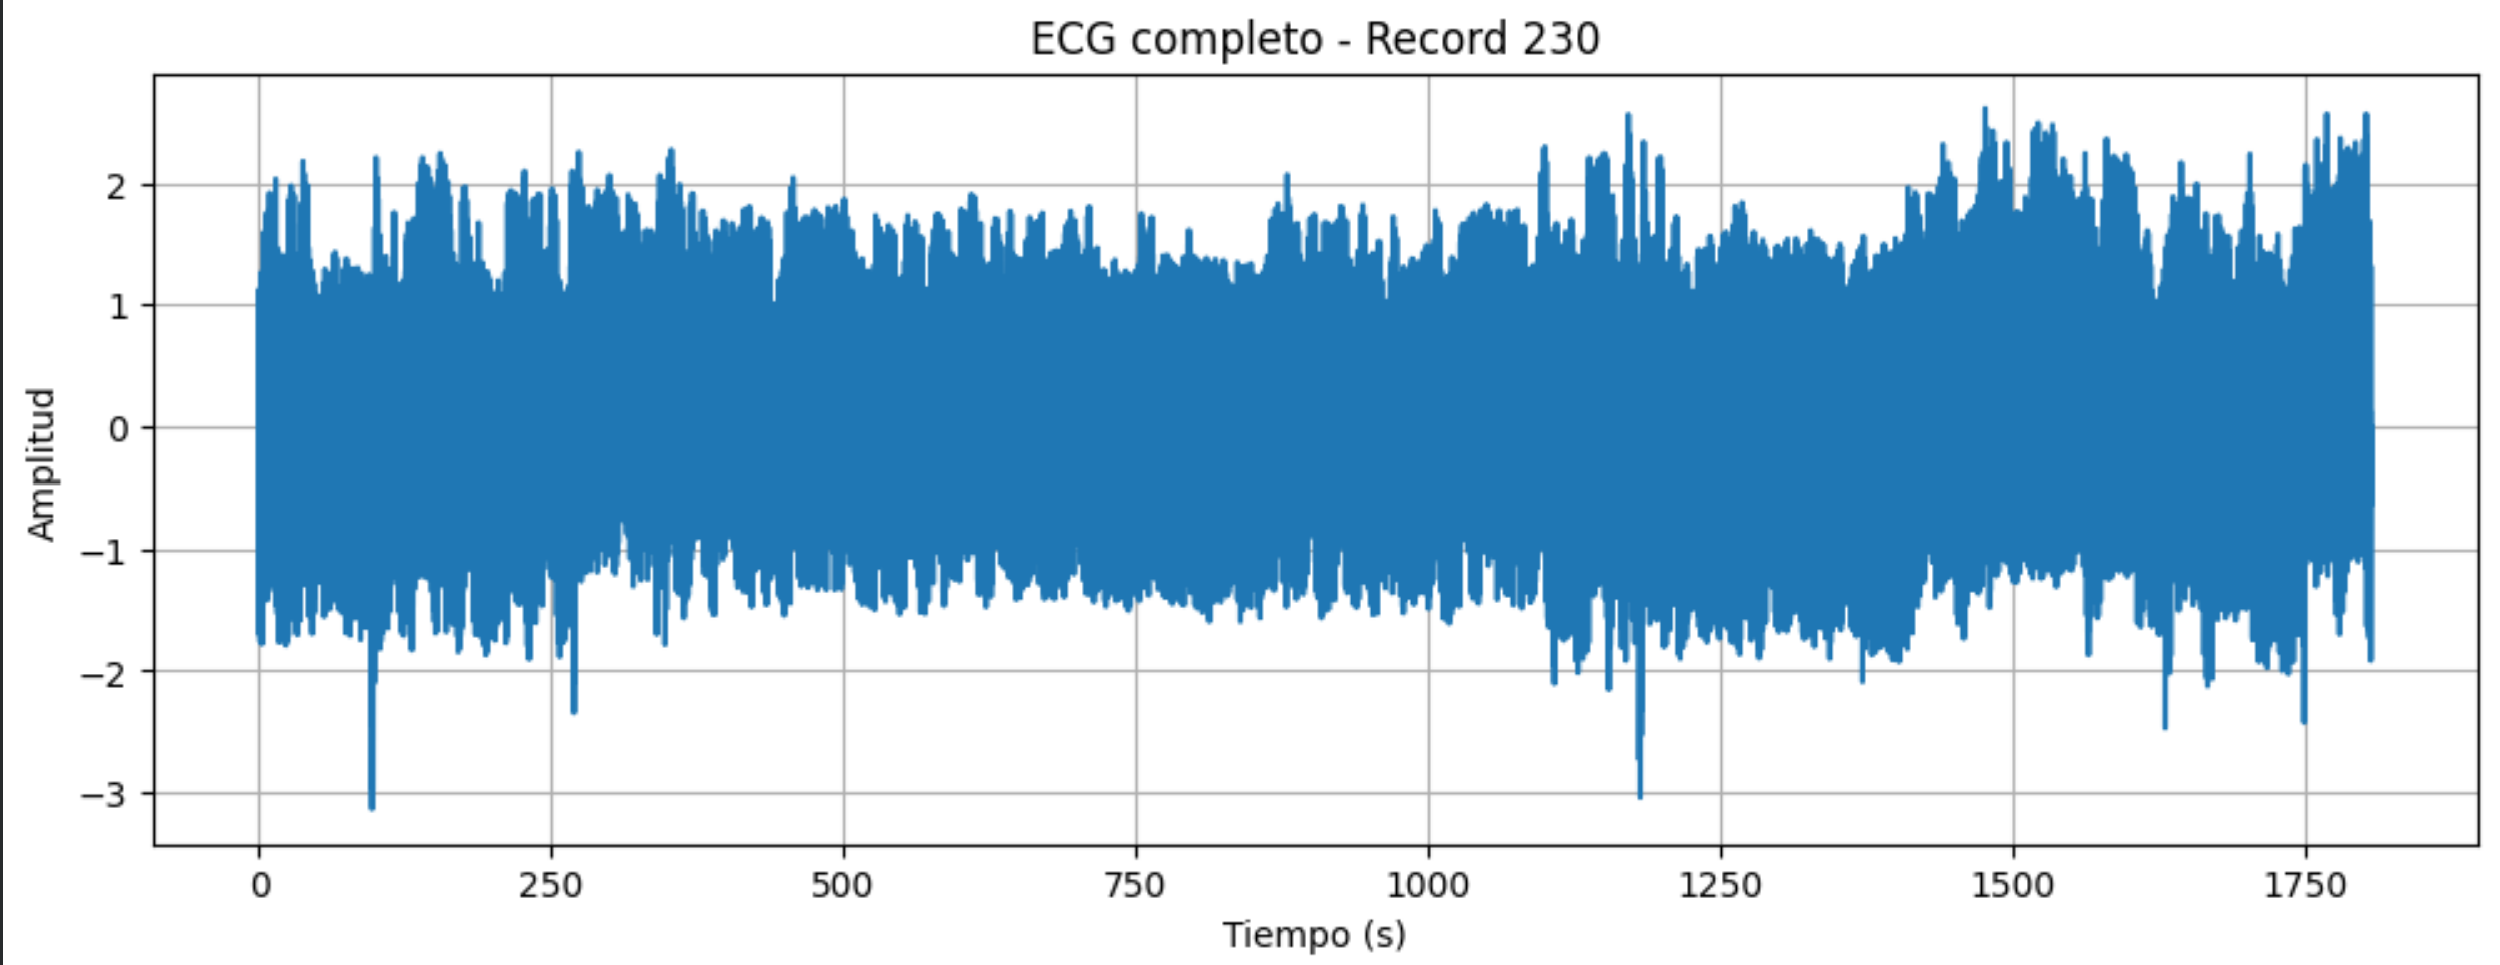

6.2) Segunda gráfica - ECG primeros 10 segundos

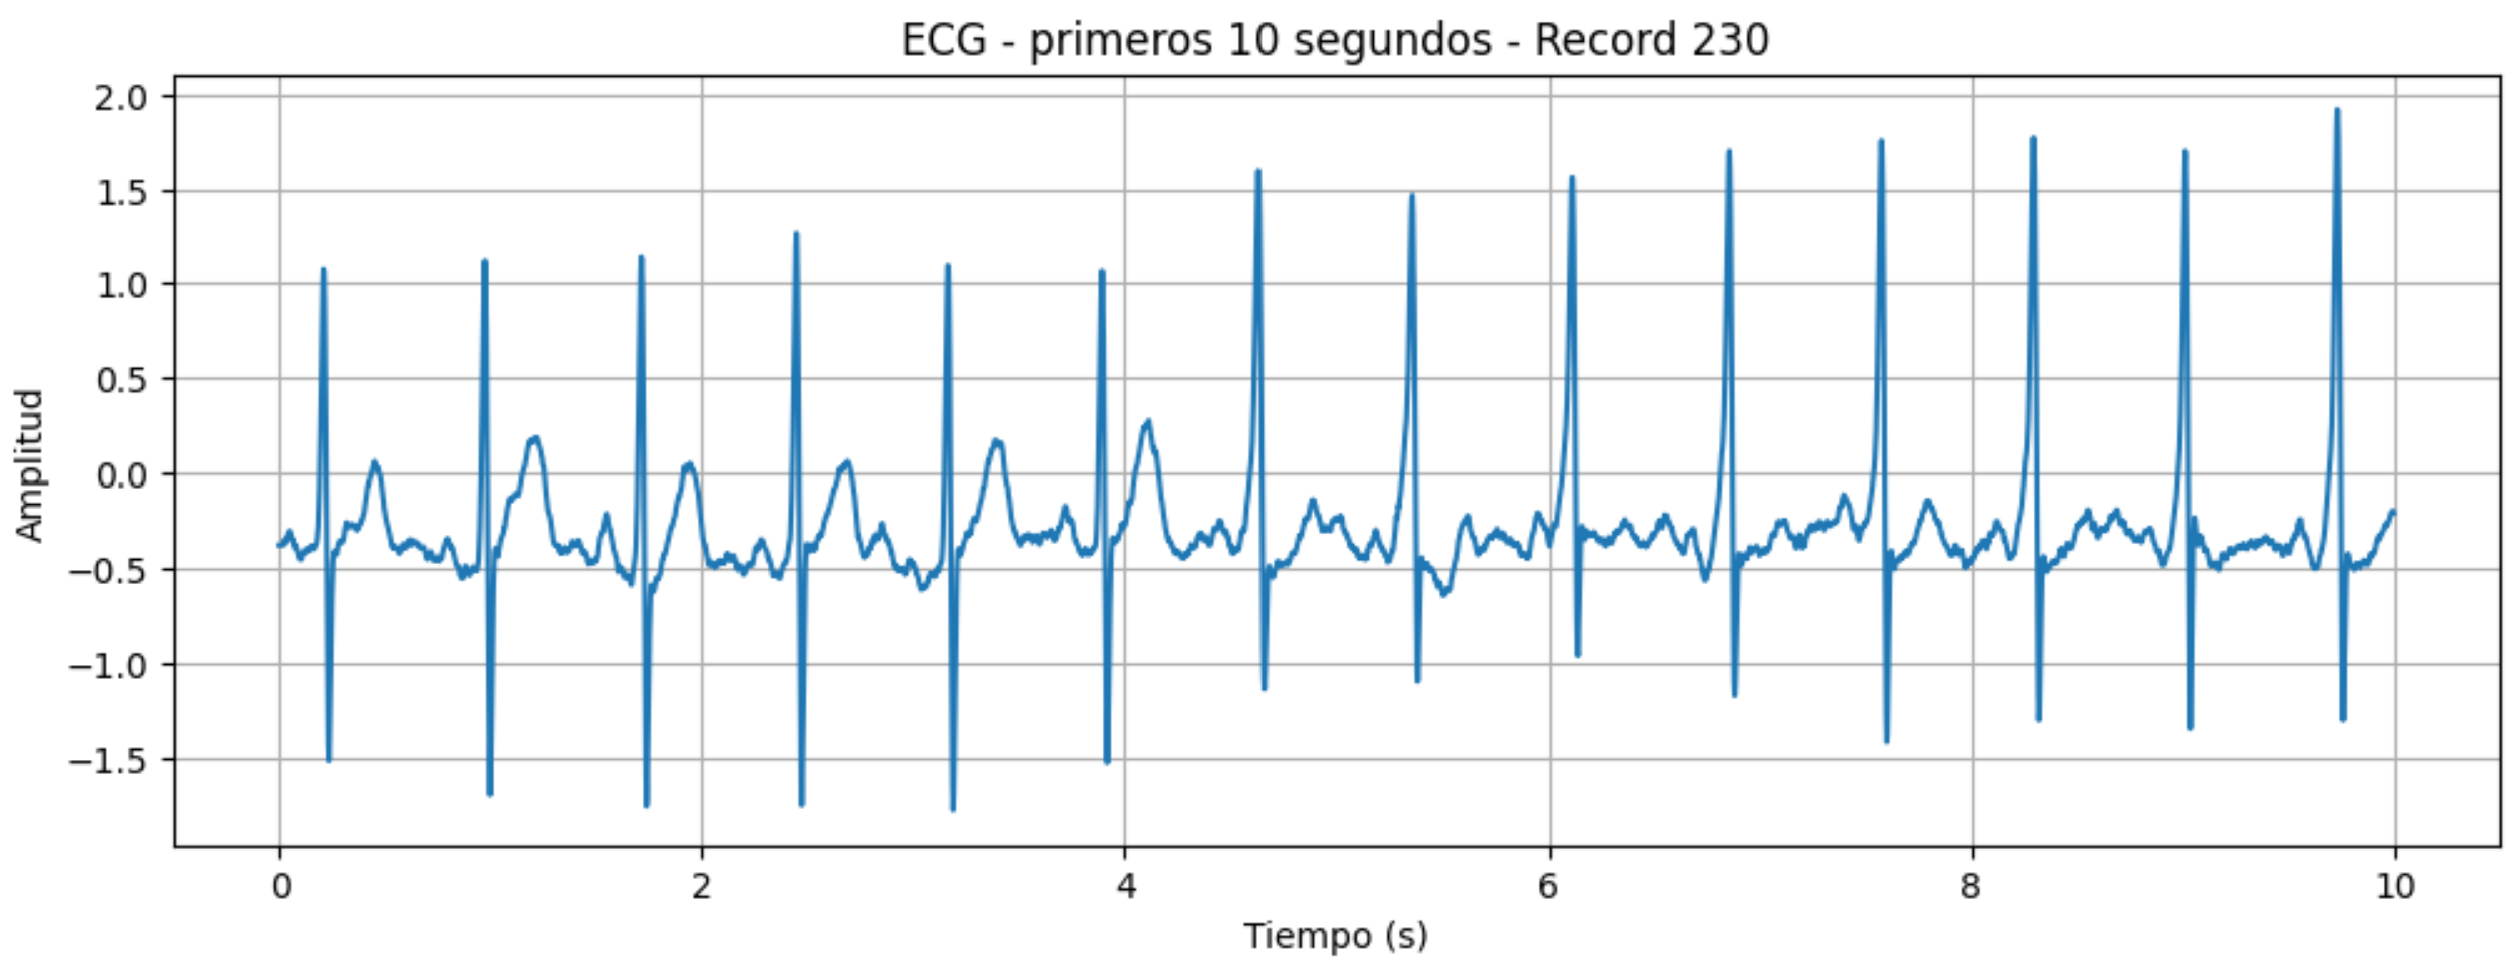

6.3) Tercera gráfica - Histograma

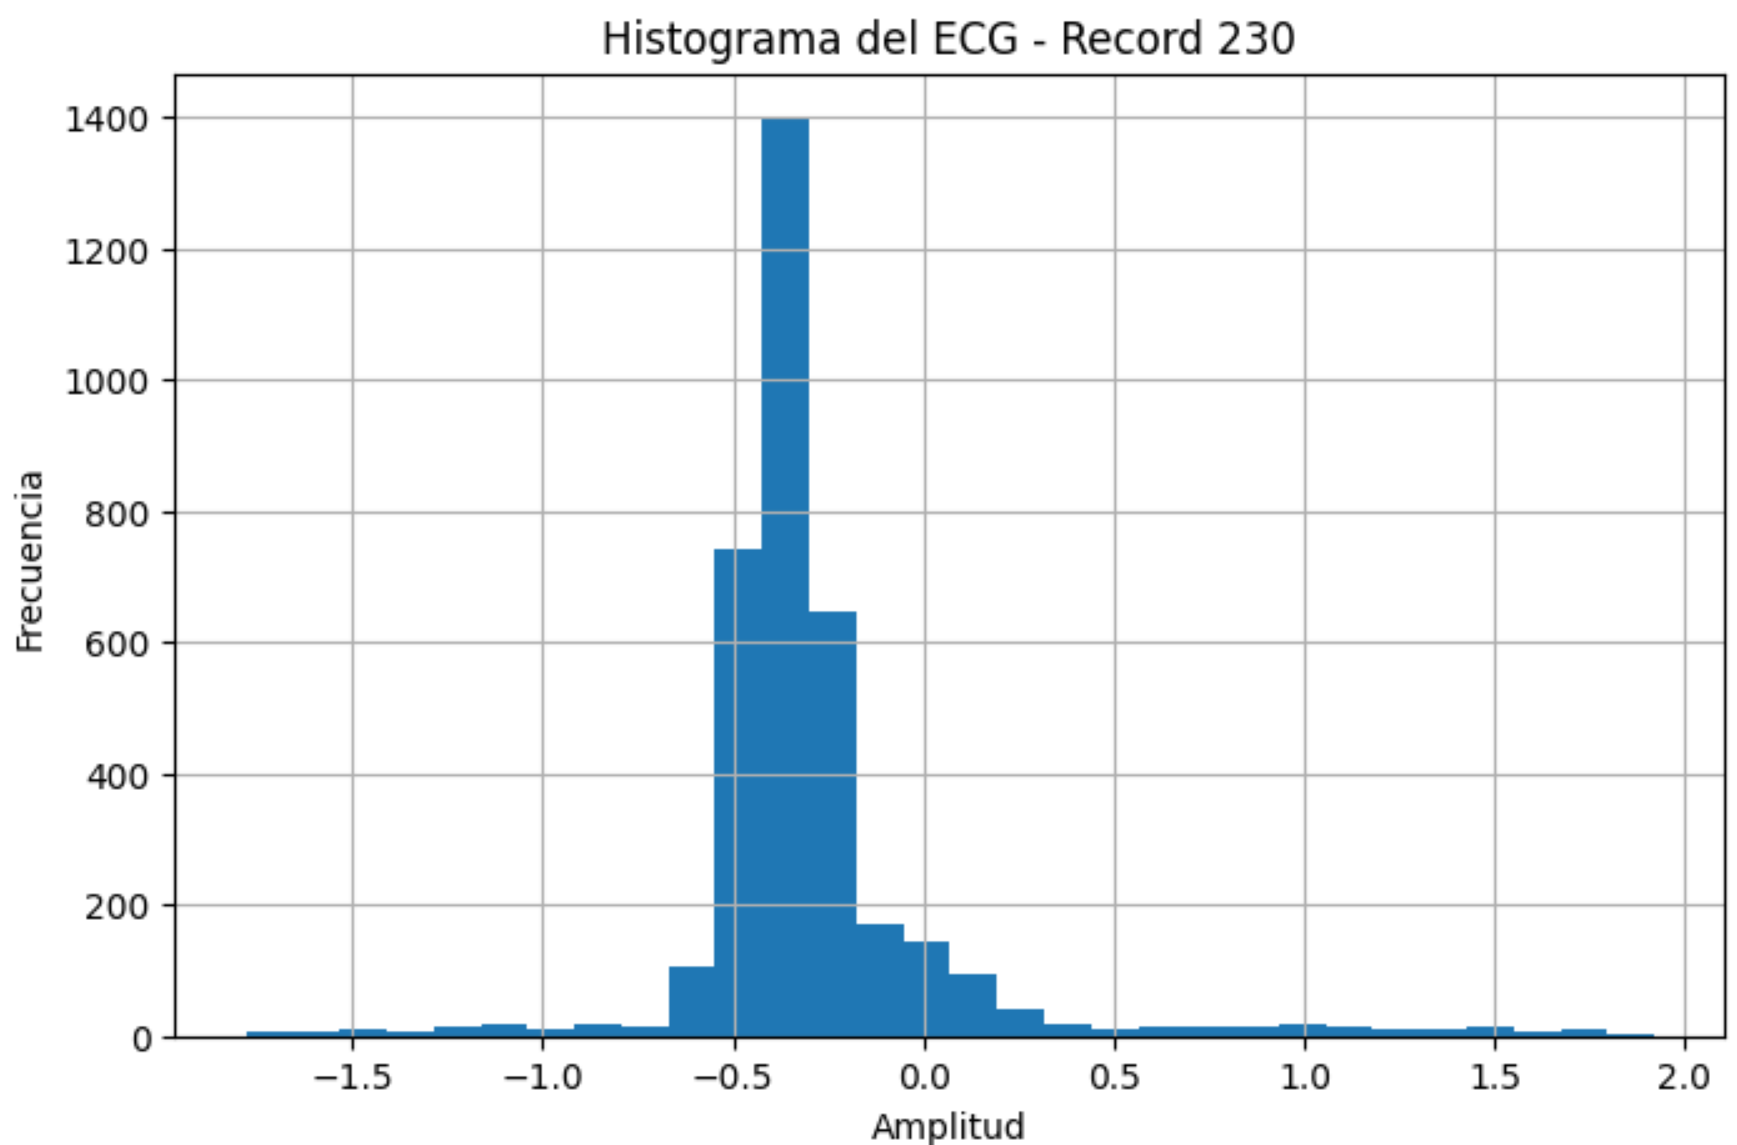

6.4) Cuarta gráfica - Representación discreta

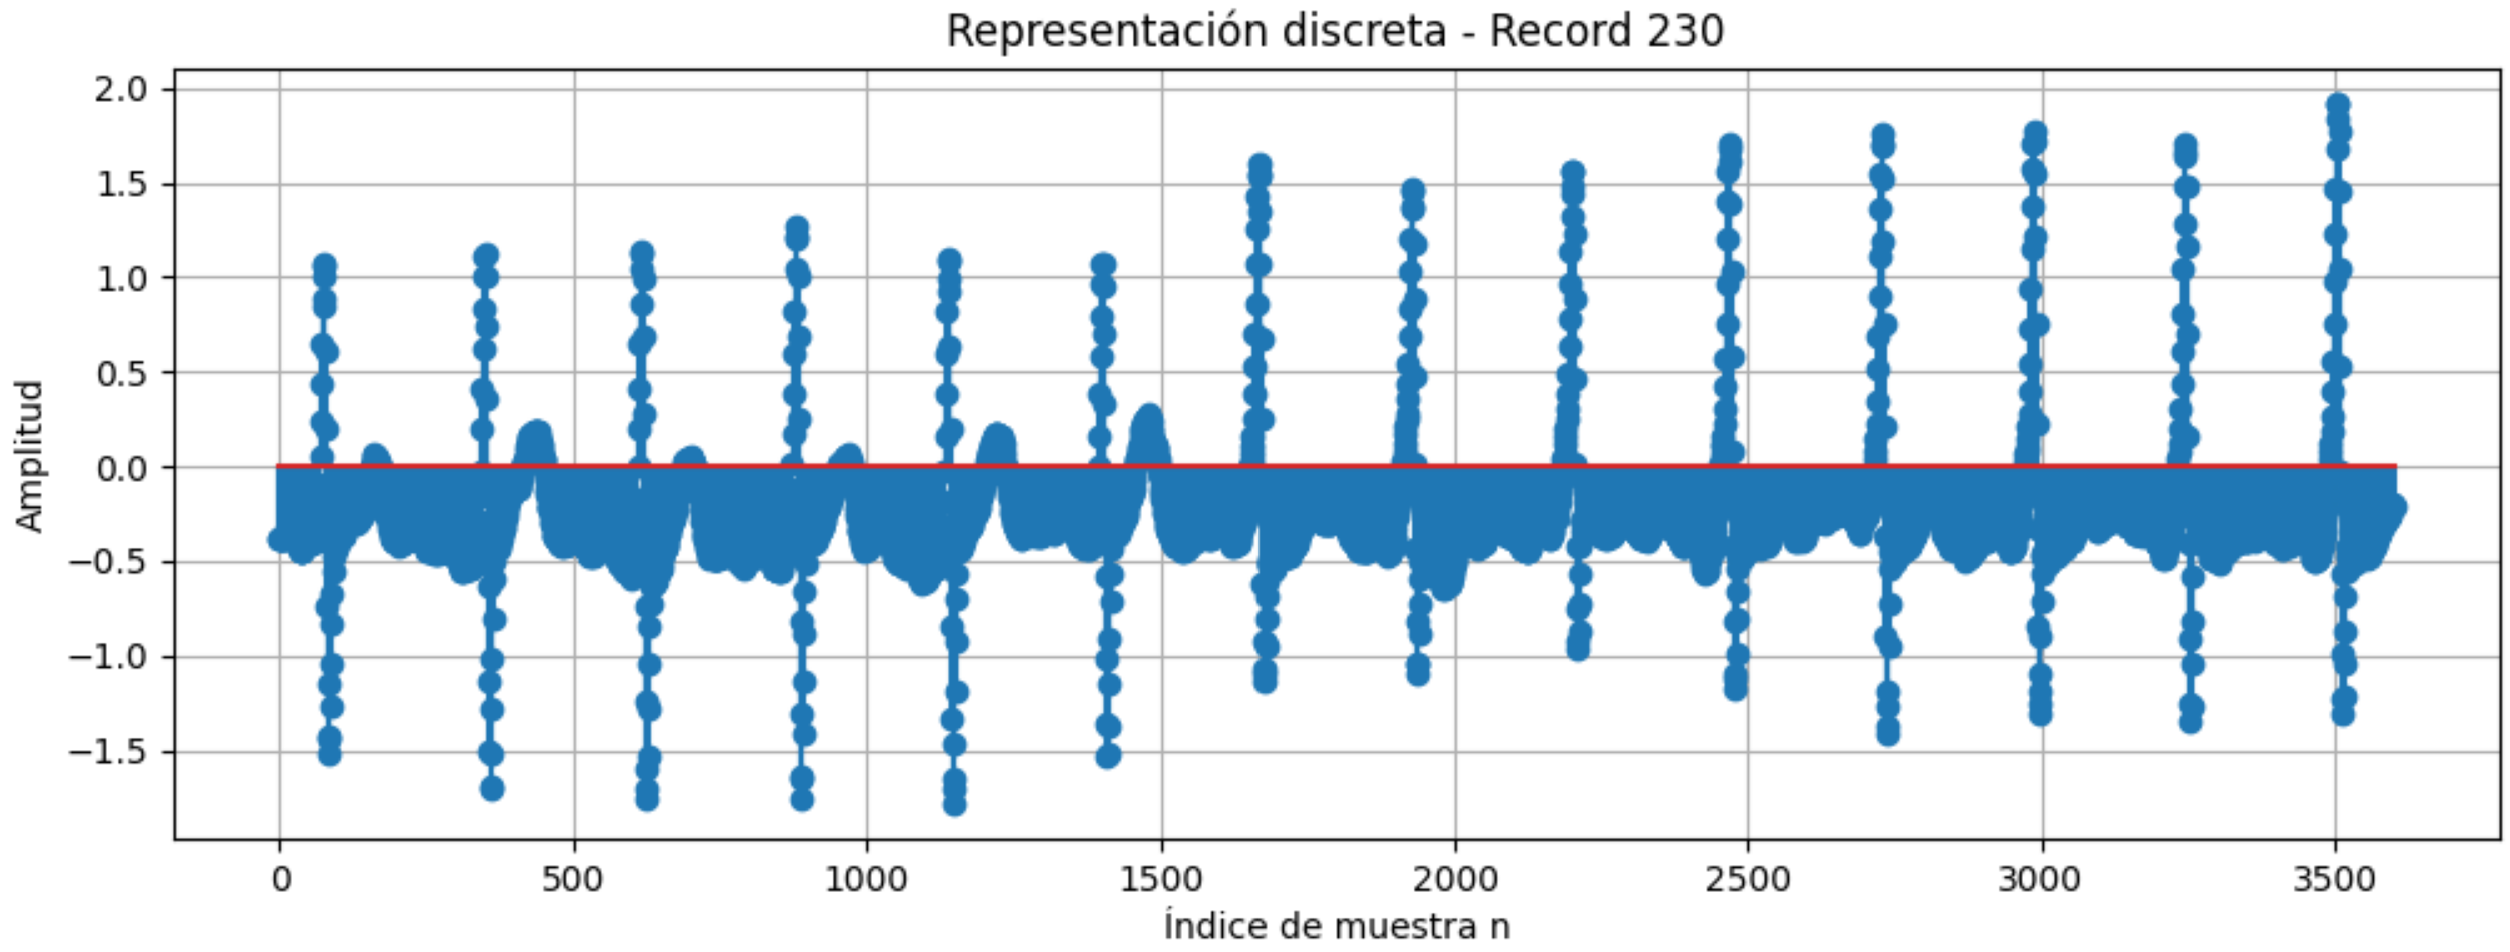

7) Estadísticas

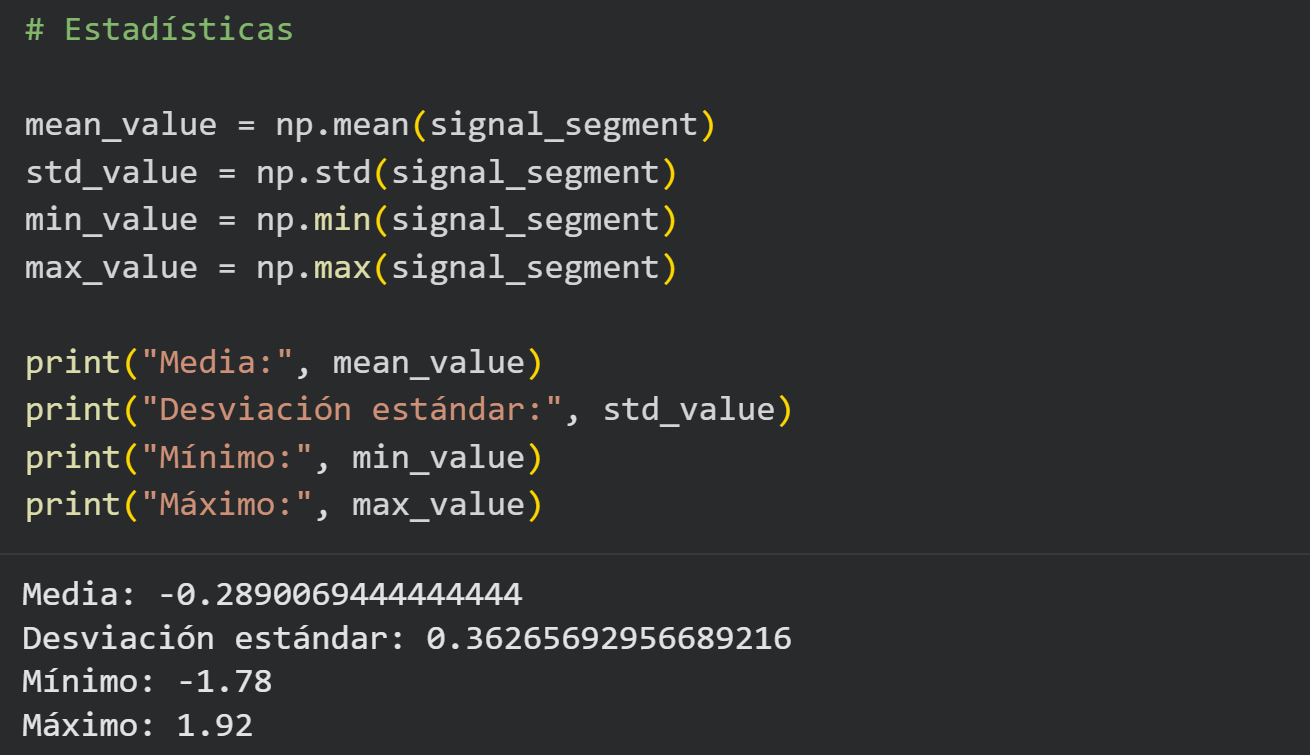

8) Archivo WAV

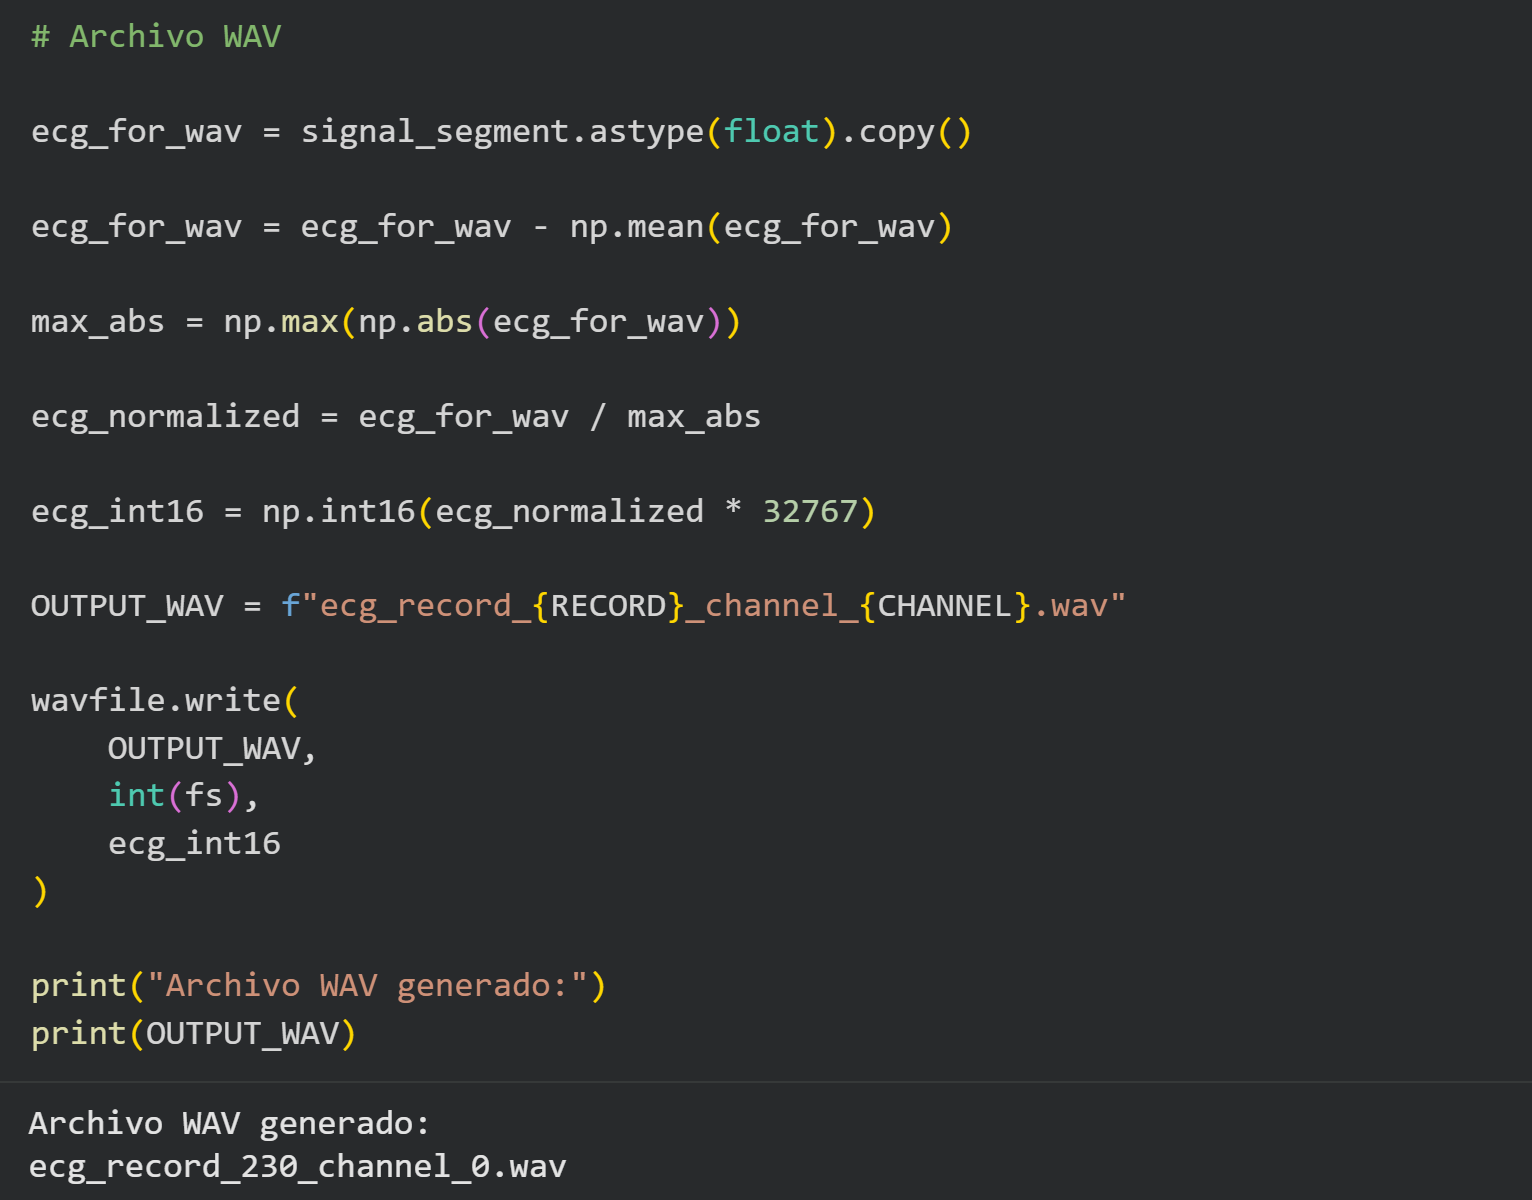

9) Interpretación de resultados

- En la gráfica ECG completa, si bien esta conserva una morfología similar a la del registro 100, esta posee un mayor rango de amplitud ya que va de -2 a 2 aproximadamente mientras que en el registro 100 va de -1 a 1. Además se observan ciertas perturbaciones que se observaban menos en el registro 100. Estas variaciones de amplitud son características de una señal electrocardiográfica.

- En la gráfica de los primeros 10 segundo de ECG,  el rango de amplitud vuelve a ser mayor ya que en este regitro es de -1.5 a 2 aproxiamdamente mientras que en el registro 100 es de -0.6 a 1 aproximadamente. Además, en este registro se observa como en un momento la señal ECG empieza a poseer mayores valores en el eje y, mientras que en el anterior registro, estos se mantienen siempre en el mismo rango. Estas variaciones de amplitud son características de una señal electrocardiográfica.

- En la grafica de histograma, si bien ambos rangos de mayor concentración de mayor numero de muestras es similar en el eje de amplitud. En este registro el máximo número de muestras ronda los 1400 mientras que en el registro 100 ronda los 800. Los valores extremos poseen una menor frecuencia de muestras.

- En la grafica de representación discreta, se demuestras que esta señal continua se puede representar por muestras discretas, sin que se modifique en tal punto la morfología que pierda similutd con la señal continua.

- La media de −0.289 mV indica que, durante los 10 segundos analizados, los valores de amplitud de la señal ECG se encuentran ligeramente por debajo de 0 mV.  La desviación estándar de 0.363 mV indica que existe una variación apreciable de los valores de amplitud alrededor de la media, que se menciono anteriormente. El valor mínimo de −1.78 mV y el máximo de 1.92 mV indican que, durante el segmento analizado, la señal presentó un rango de amplitud de 3.70mV.

10) Conclusiones

- Se consiguió seleccionar un registro diferente dentro de la misma base de datos y a raíz de este interpretar distintos resultdos de acuerdo a las gráficas obtenidas y estadísticas

- Se lograron identificar las principales características de la señal del registro seleccionado

- Se consiguió representar la señal ECG mediante una represetnación continua y discreta

- La señal ECG fue convertida a archivo WAV


# 21. Conclusiones esperadas

Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
